In [ ]:
# Author: Miguel Aenlle

In [2]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel

In [3]:
output_data_paths = ['output/output_data.json']

In [4]:
# Load the JSON data
all_output_data = []
for output_data_path in output_data_paths:
    if os.path.exists(output_data_path):
        with open(output_data_path, 'r') as file:
            output_data = json.load(file)
            print(len(output_data))
            for model_data in output_data:
                all_output_data.append(model_data)

20


In [5]:
output_data = all_output_data

In [7]:
model_shortnames = {
    'uwm-unet-train-set-size-288': "Improved UNet",
    'uwm-unet-singan-train-set-size-861': "SinGAN-augmented, n=861",
    'uwm-unet-singan-finetuning-train-set-size-861': "SinGAN-finetuned, n=861",
    'uwm-unet-singan-finetuned-n-10-10x-train-set-size-861': "SinGAN-FT-augmented, n=861"
}

In [8]:
cv_subjects = set([model_data['cv_subject'] for model_data in output_data])

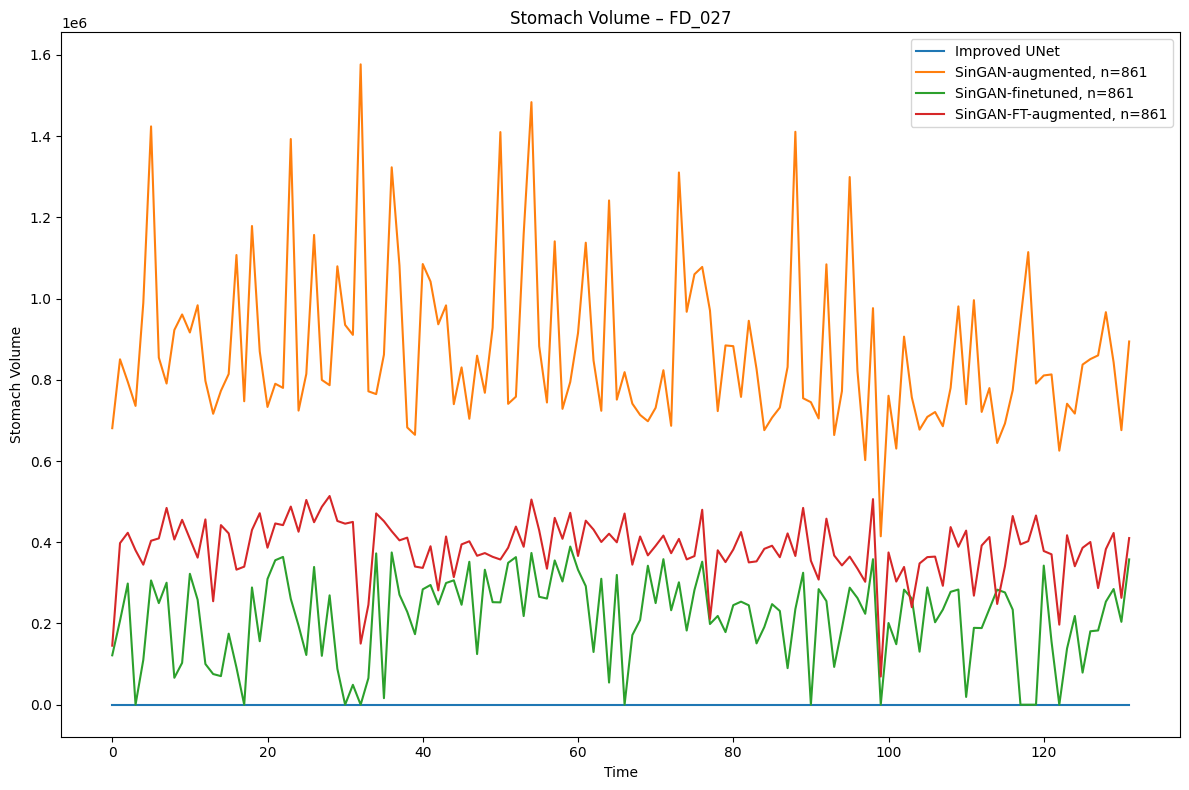

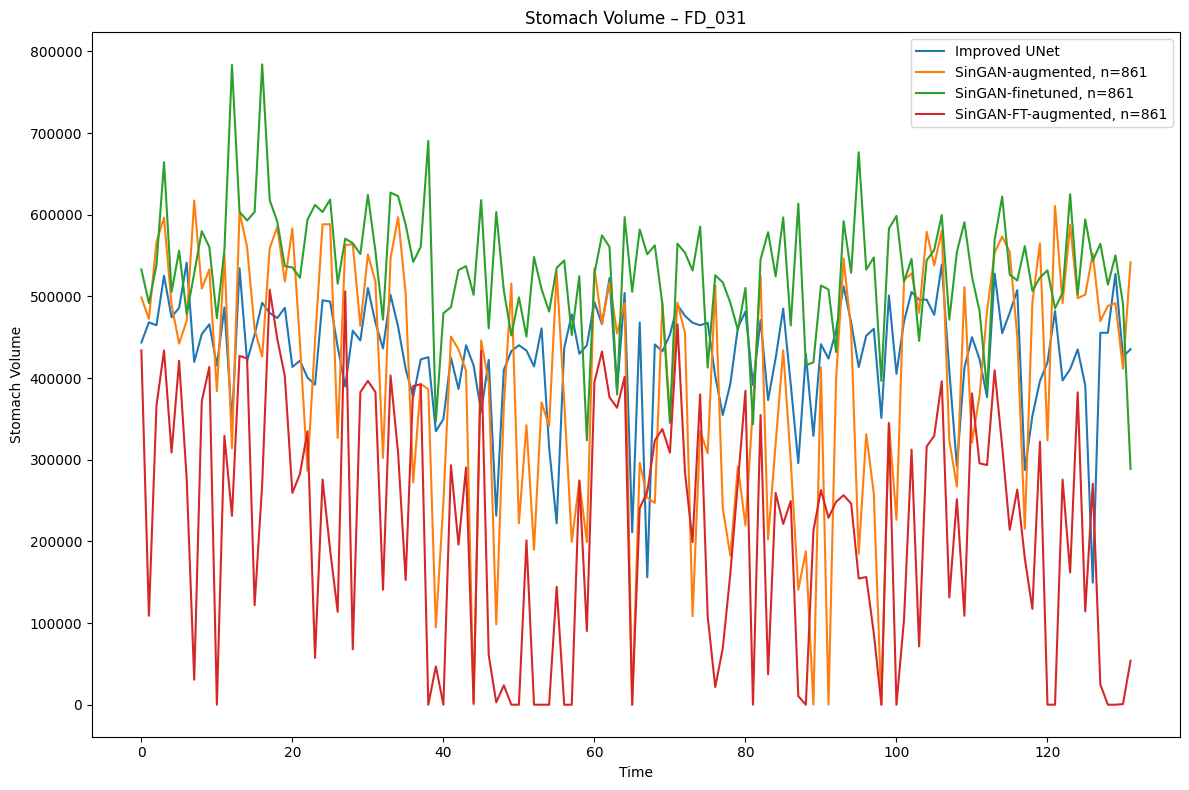

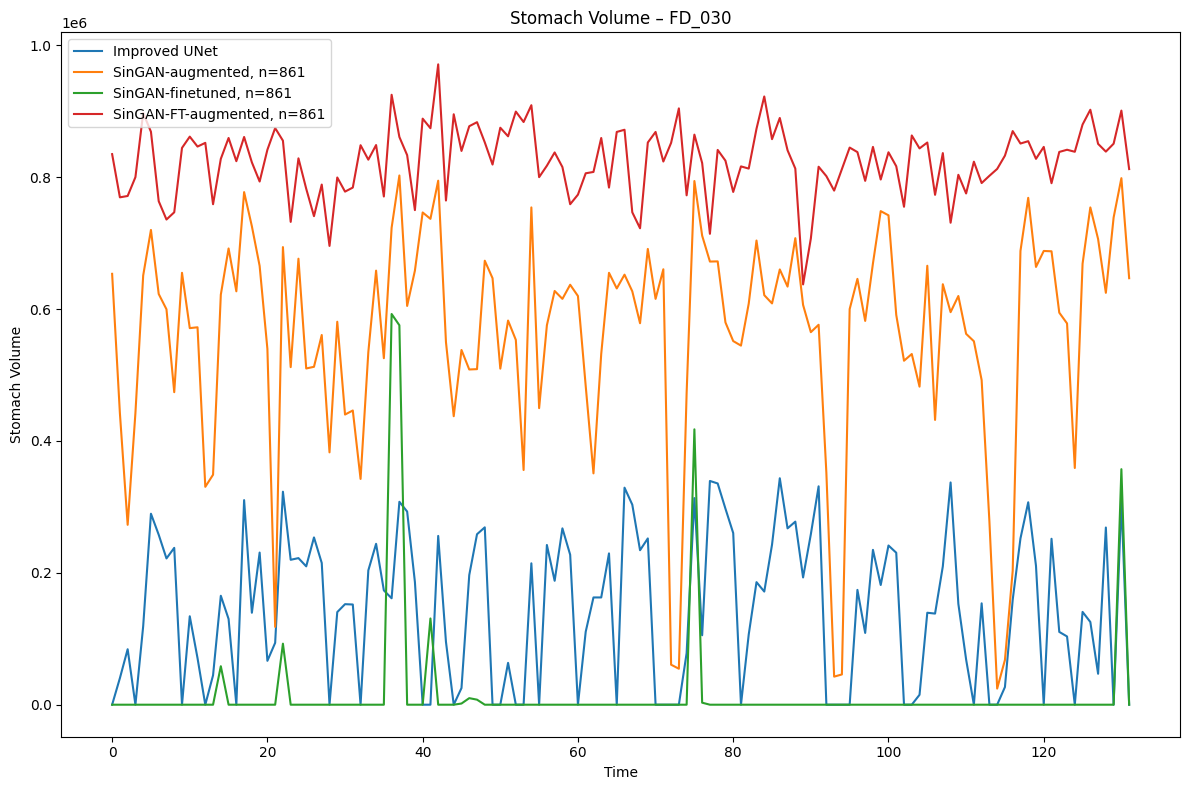

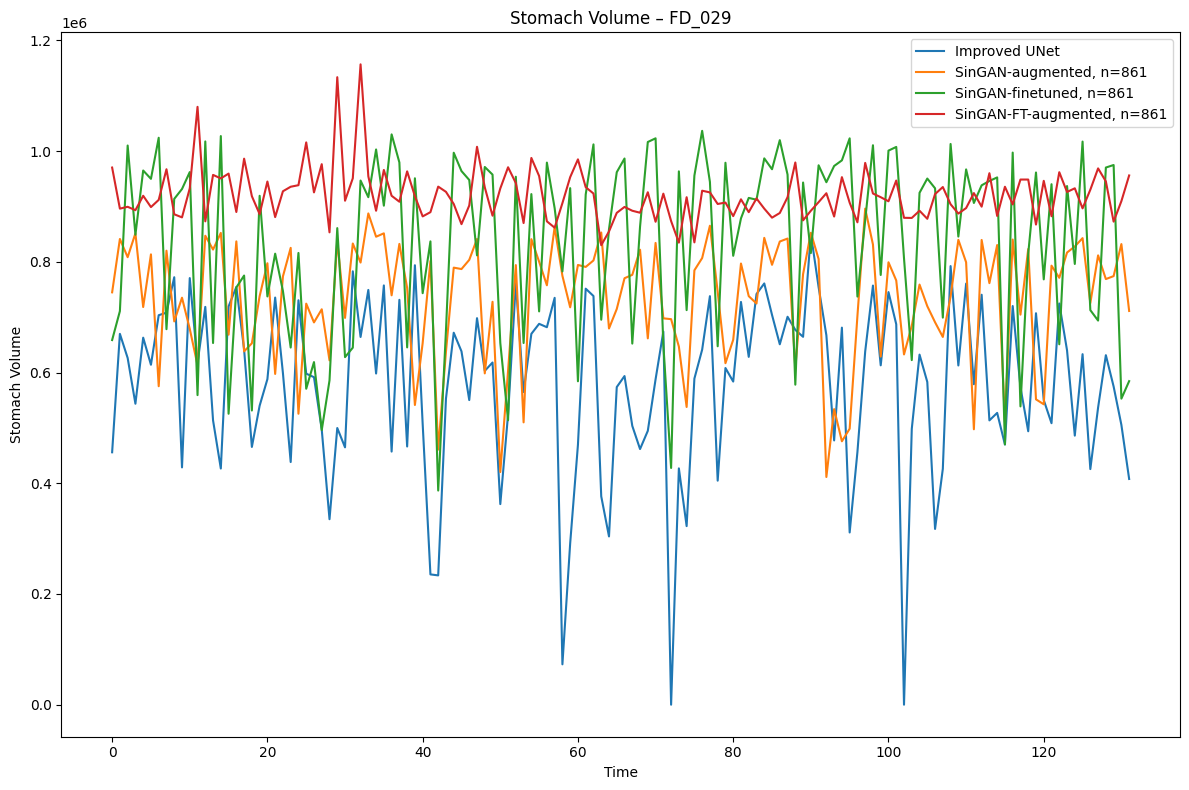

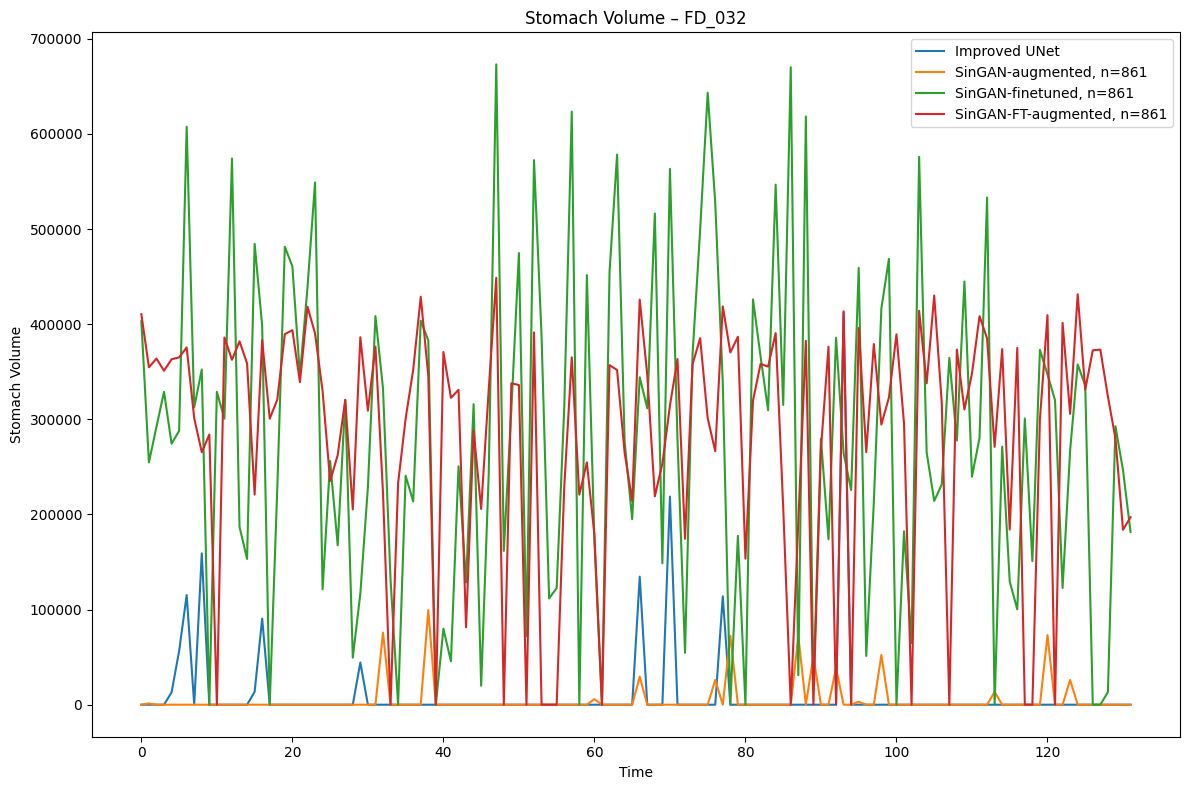

In [10]:
for cv_subject in cv_subjects:
    fig, ax = plt.subplots(figsize=(12, 8))
    for model_data in output_data:
        if model_data['cv_subject'] == cv_subject:
            ax.plot(
                model_data['mid_slice_cross_sectional_area_uncentered'],
                label=model_shortnames[model_data['model']]
            )
    ax.set(
        xlabel='Time',
        ylabel='Stomach Volume',
        title=f'Stomach Volume – {cv_subject}'
    )
    ax.legend()
    fig.tight_layout()
    plt.show()

In [11]:
len(output_data)

20

In [12]:
1

1

In [13]:
import re
def parse_matlab_output(text):
    # 1) stomachMask size: four ints on one line
    size_m = re.search(
        r"Size of stomachMask:\s*([\d]+\s+[\d]+\s+[\d]+\s+[\d]+)", 
        text
    )
    stomach_mask_size = tuple(map(int, size_m.group(1).split()))

    # 2) dominant frequency: one float
    dom_m = re.search(
        r"Dominant Frequency \(Hz\):\s*([0-9]*\.?[0-9]+)", 
        text
    )
    dominant_frequency_hz = float(dom_m.group(1))

    # 3) wave speeds block up until the Warning (or end of string)
    wave_m = re.search(
        r"Wave propagation speeds \(mm/s\):\s*(.*?)(?=Warning:|$)",
        text,
        re.DOTALL
    )
    wave_block = wave_m.group(1)

    # extract all floats, 'Inf', or 'NaN'
    raw_speeds = re.findall(r"-?\d*\.\d+|Inf|NaN", wave_block)

    # convert: Inf → +inf, NaN → 0.0, else float
    wave_propagation_speeds_mm_s = []
    for x in raw_speeds:
        if x == "Inf":
            wave_propagation_speeds_mm_s.append(float("inf"))
        elif x == "NaN":
            wave_propagation_speeds_mm_s.append(0.0)
        else:
            wave_propagation_speeds_mm_s.append(float(x))

    return stomach_mask_size, dominant_frequency_hz, wave_propagation_speeds_mm_s

In [14]:
results = {}
for md in output_data:
    subj = md['cv_subject']
    size, freq, speeds = parse_matlab_output(md['matlab_output'])
    entry = {
        'model': md['model'],
        'stomach_mask_size': size,
        'dominant_frequency_hz': freq,
        'wave_propagation_speeds_mm_s': speeds
    }
    results.setdefault(subj, []).append(entry)

In [15]:
import numpy as np

In [16]:
import pandas as pd

rows = []
for subj, entries in results.items():
    for entry in entries:
        rows.append({
            "Subject": subj,
            "Model": model_shortnames[entry['model']],
            "Dominant Frequency (Hz)": entry['dominant_frequency_hz']
        })

df = pd.DataFrame(rows)

# Pivot: subjects as rows, models as columns
pivot_df = df.pivot(index="Subject", columns="Model", values="Dominant Frequency (Hz)")

In [17]:
pivot_df

Model,Improved UNet,"SinGAN-FT-augmented, n=861","SinGAN-augmented, n=861","SinGAN-finetuned, n=861"
Subject,,,,
FD_027,0.0000,0.0606,0.0909,0.0530
FD_029,0.1364,0.0606,0.0909,0.0682
FD_030,0.0985,0.0985,0.0985,0.0530
FD_031,0.0985,0.0985,0.0985,0.0985
FD_032,0.1288,0.1894,0.1818,0.1970


Subject: FD_027


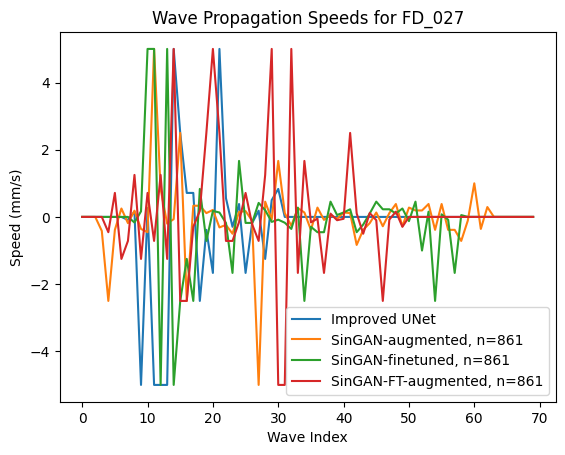

/tmp/ipykernel_1023117/568984630.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plt.imshow(t_test_p_values.fillna(1).values, vmin=-1, vmax=1, cmap='RdBu')


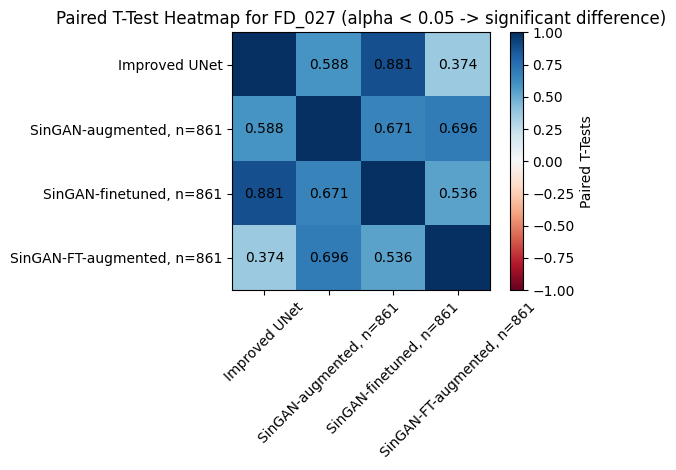

Pairs:
====


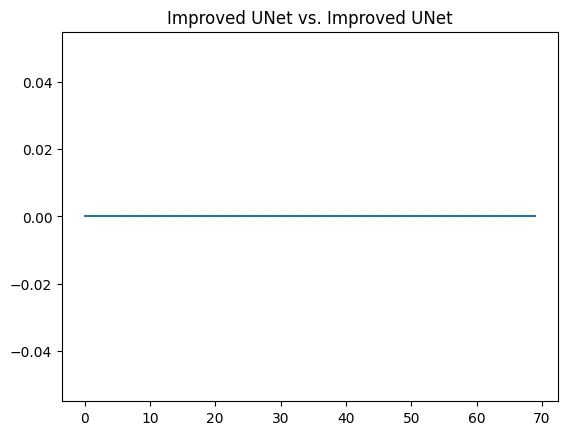

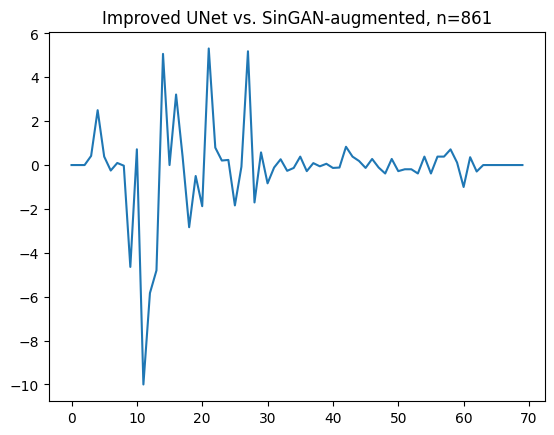

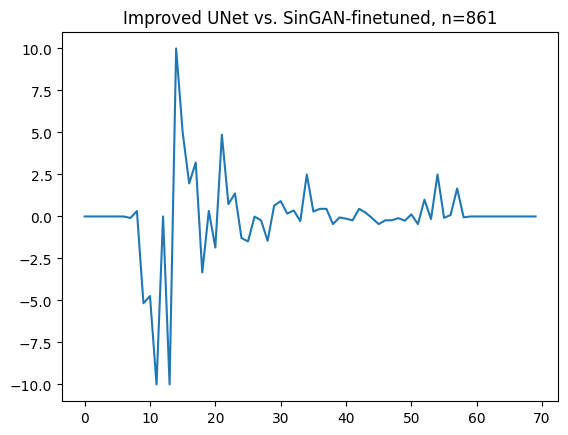

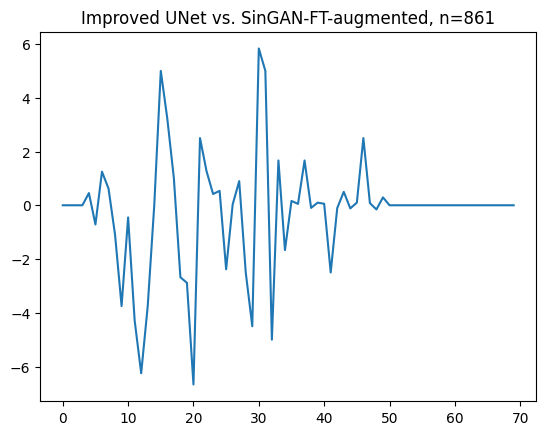

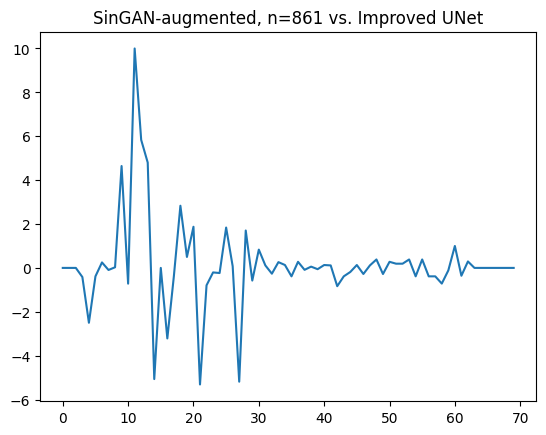

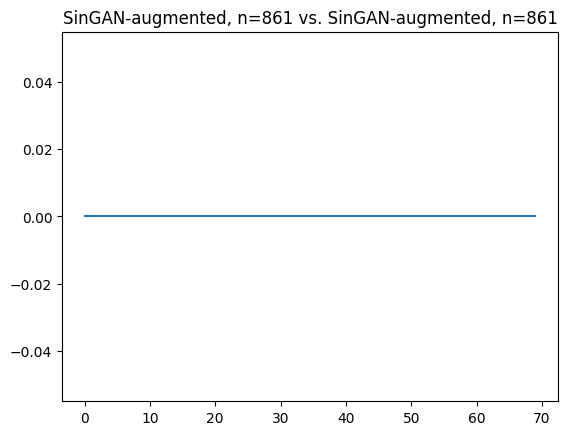

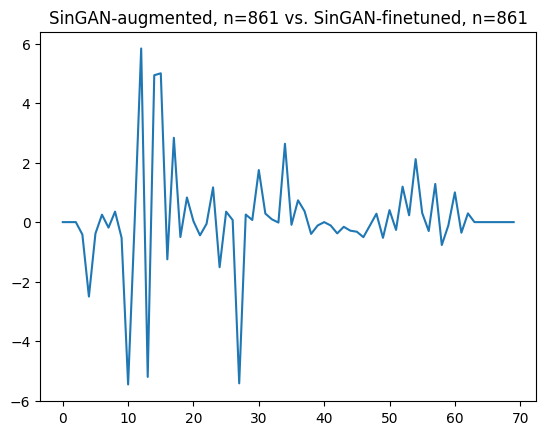

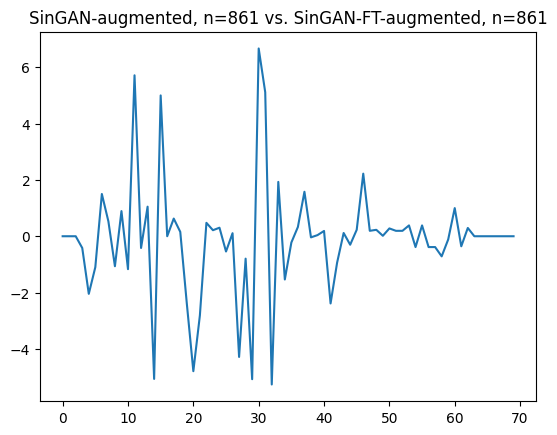

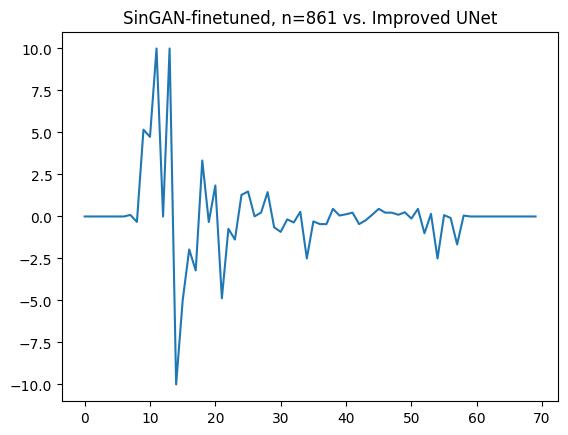

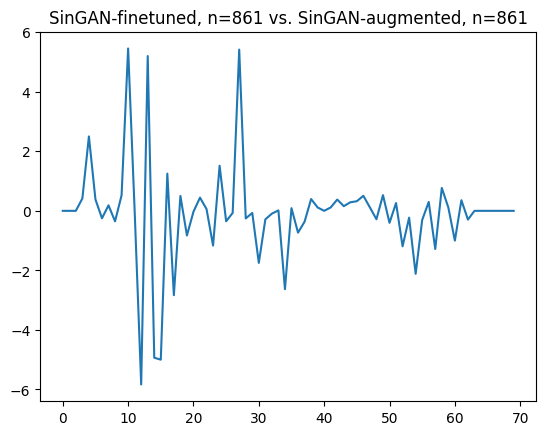

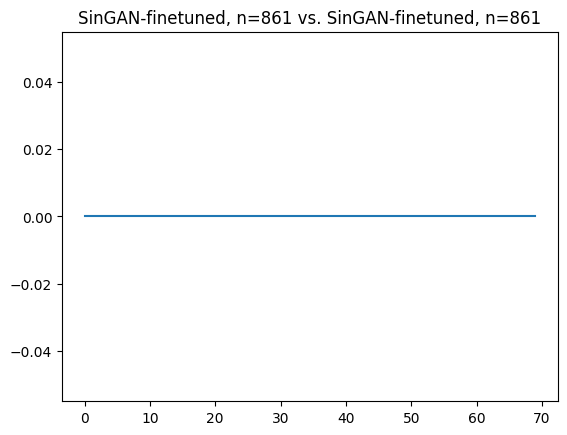

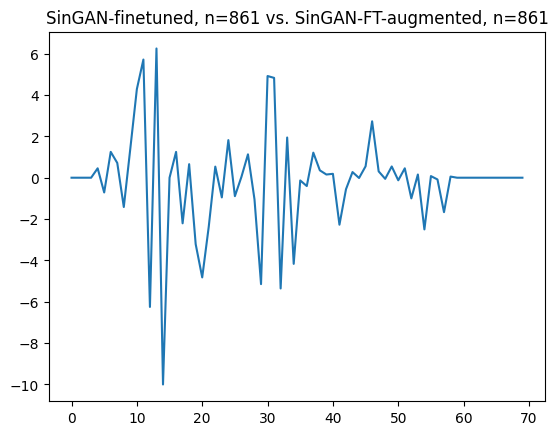

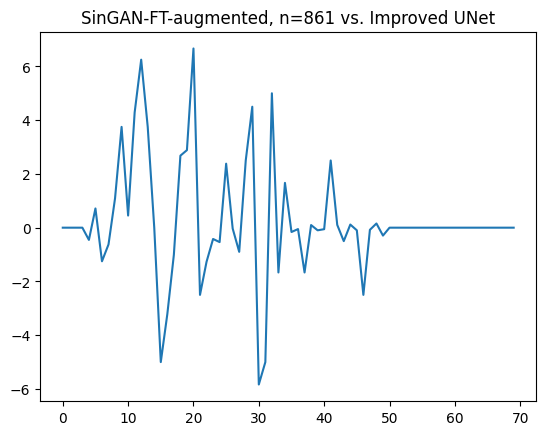

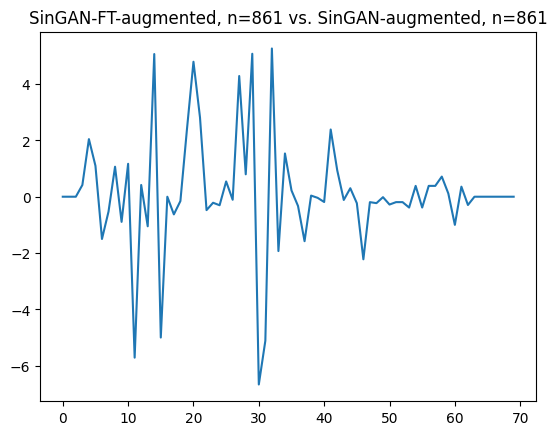

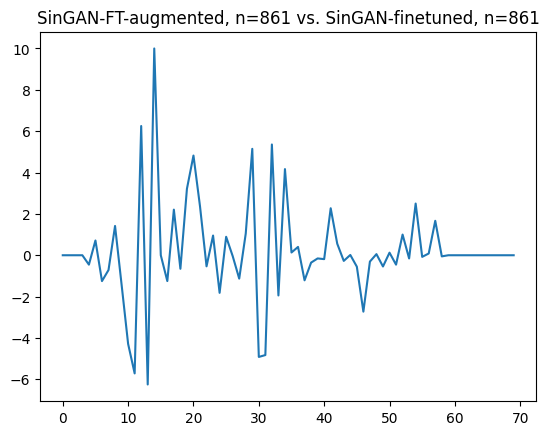

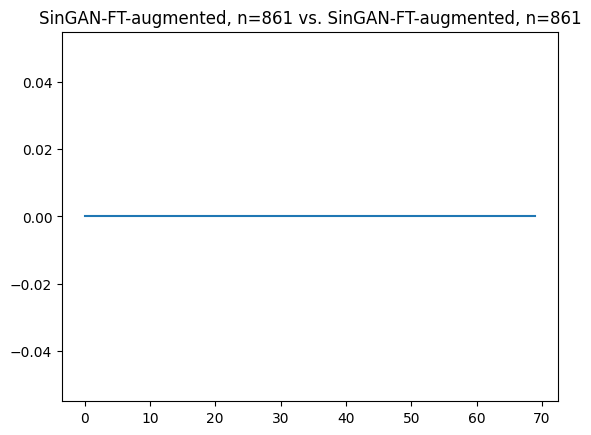

====
Subject: FD_029


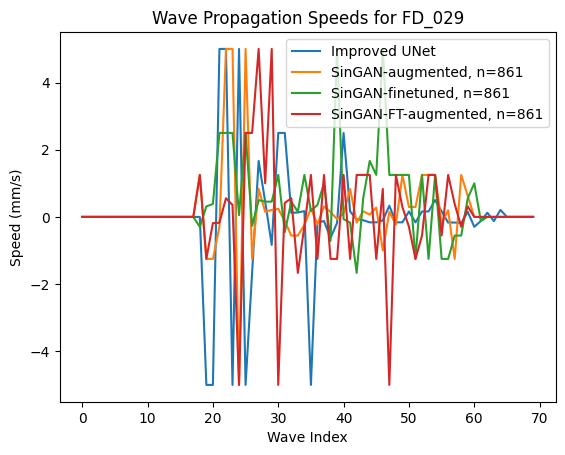

/tmp/ipykernel_1023117/568984630.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plt.imshow(t_test_p_values.fillna(1).values, vmin=-1, vmax=1, cmap='RdBu')


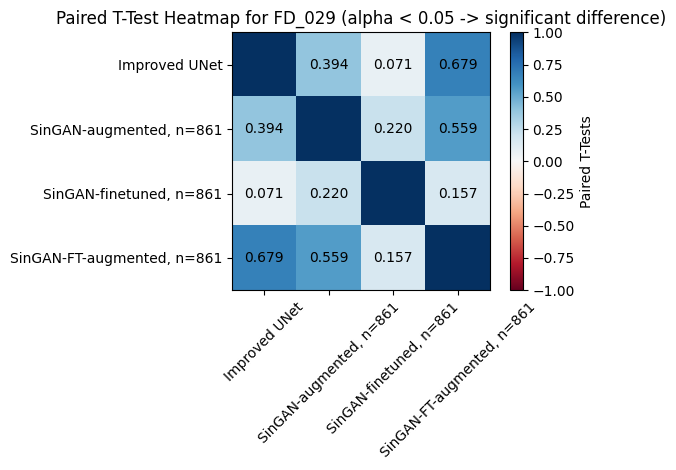

Pairs:
====


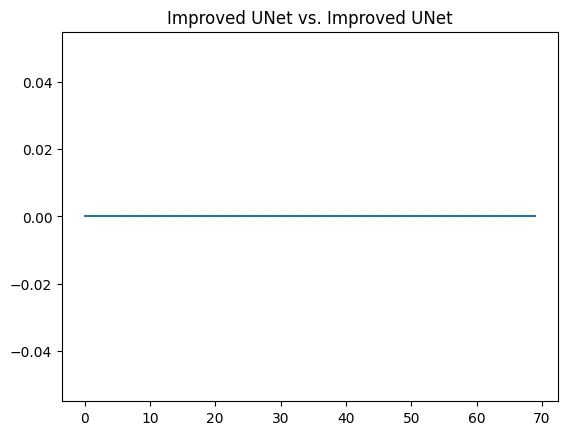

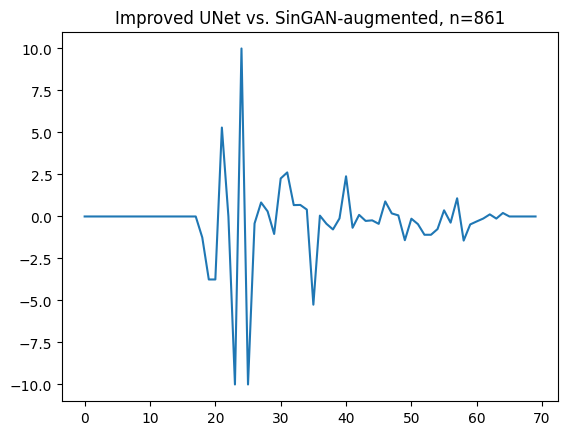

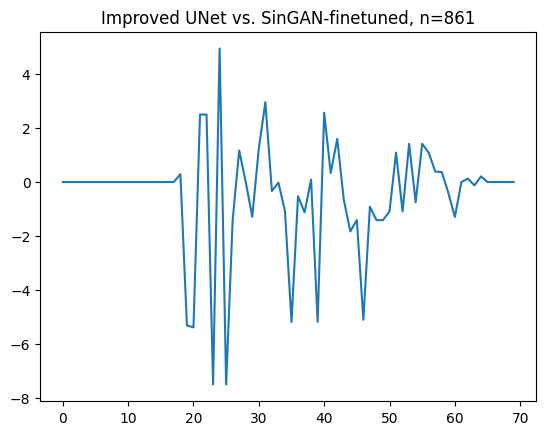

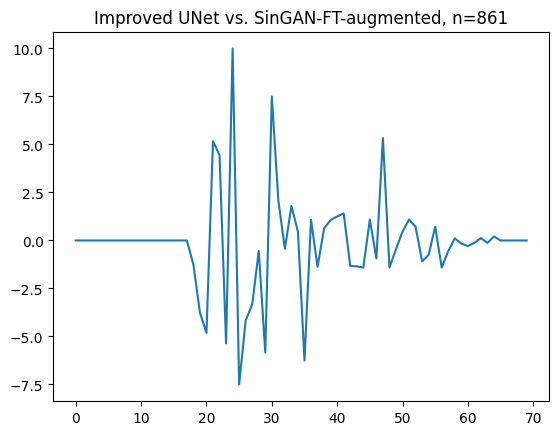

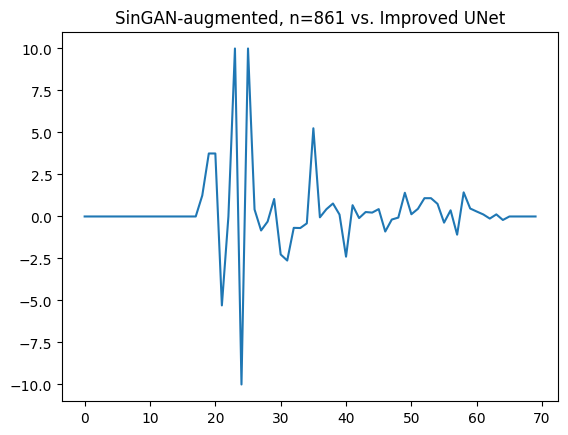

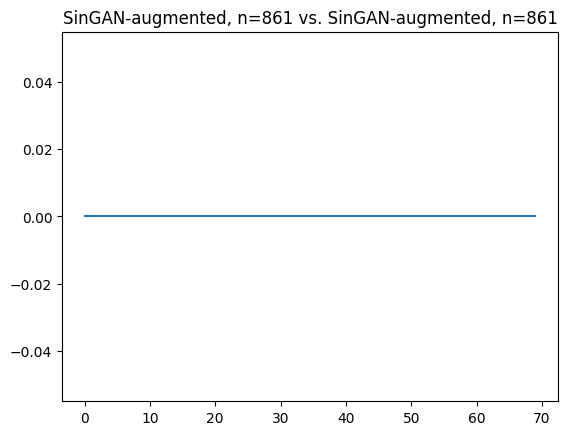

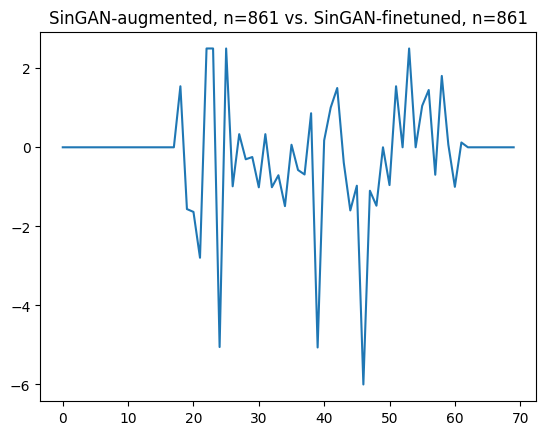

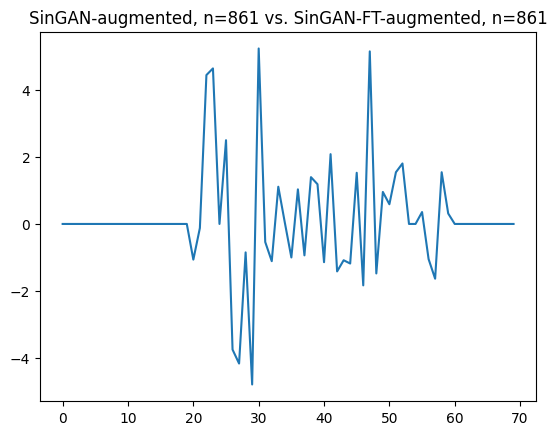

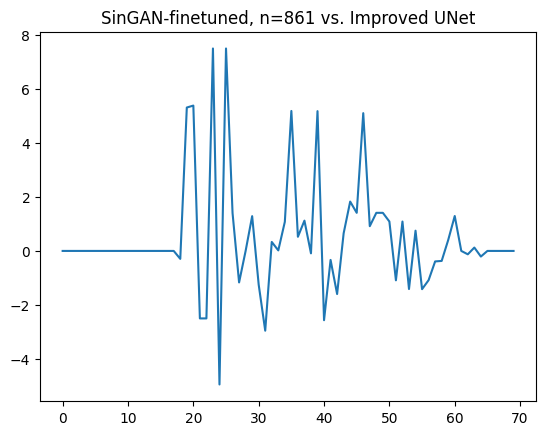

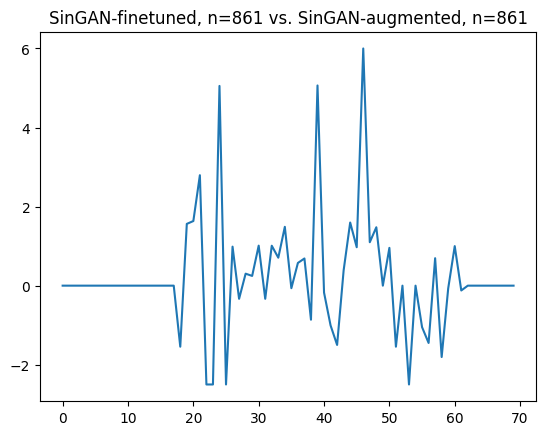

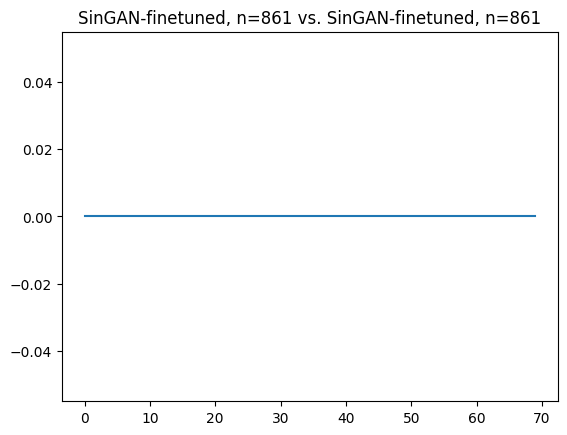

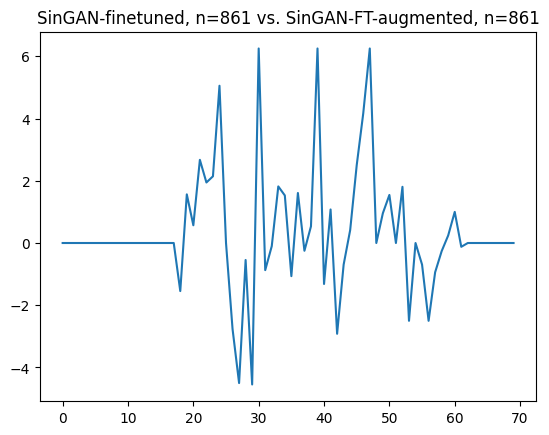

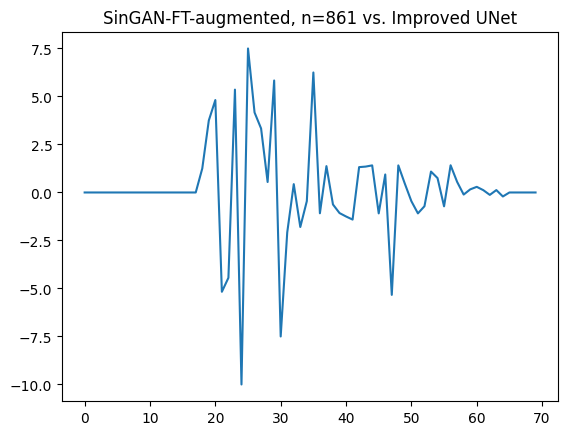

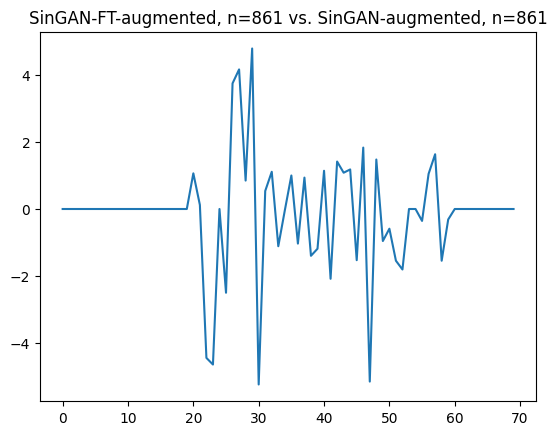

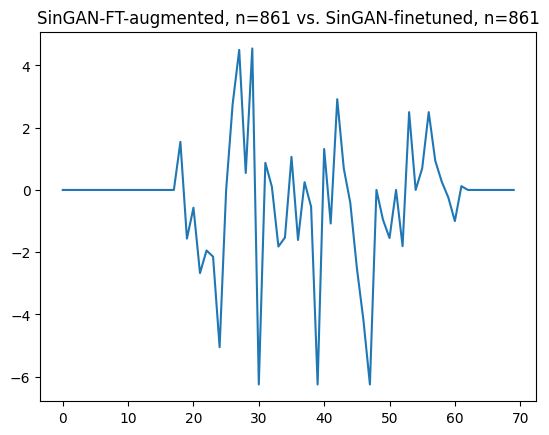

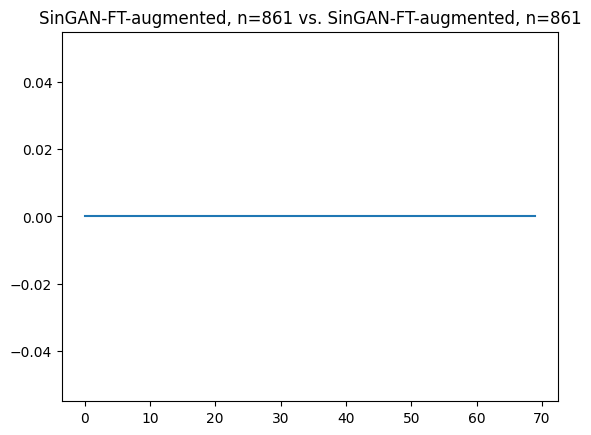

====
Subject: FD_030


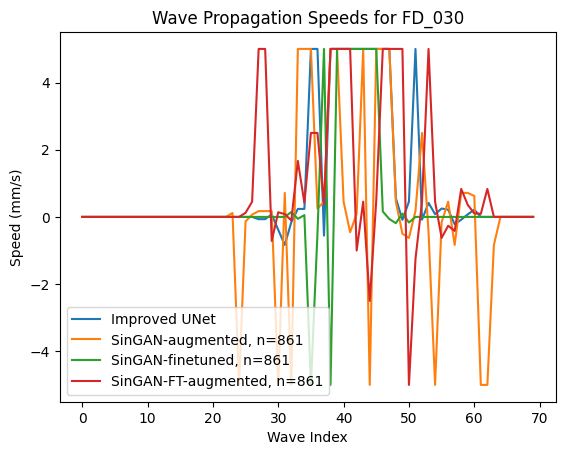

/tmp/ipykernel_1023117/568984630.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plt.imshow(t_test_p_values.fillna(1).values, vmin=-1, vmax=1, cmap='RdBu')


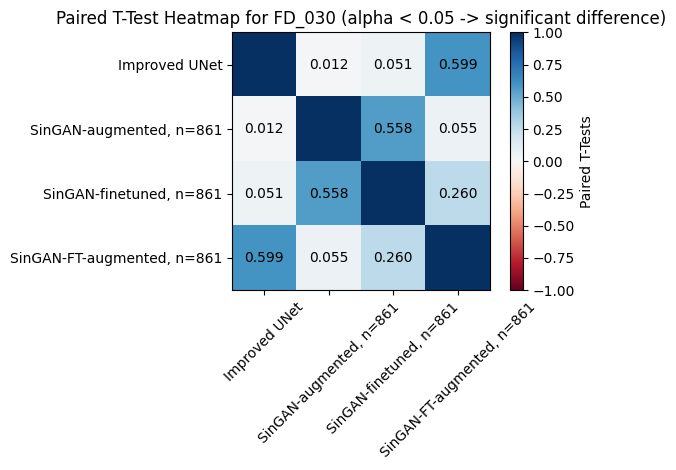

Pairs:
====


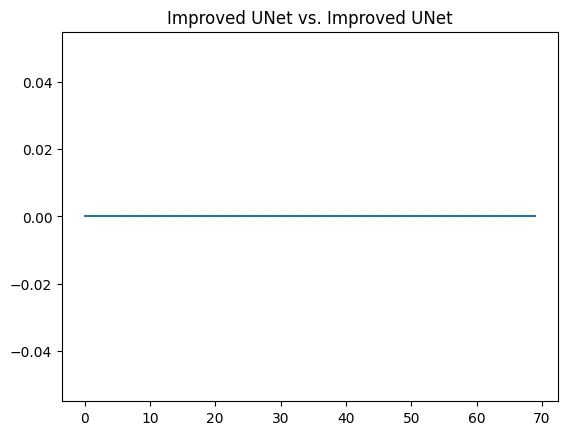

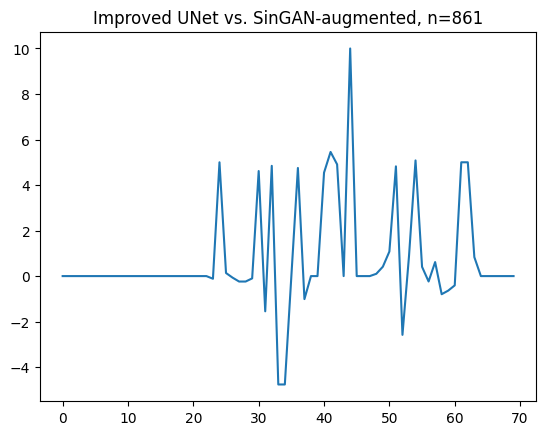

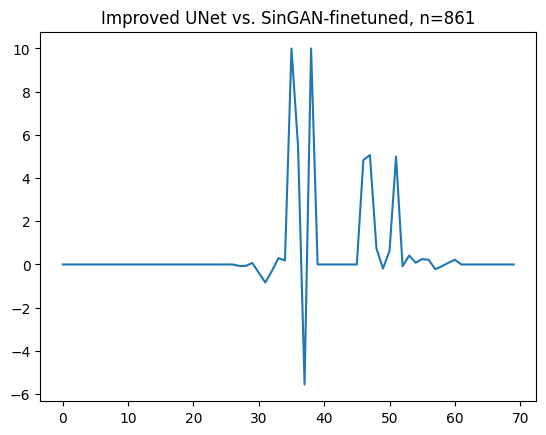

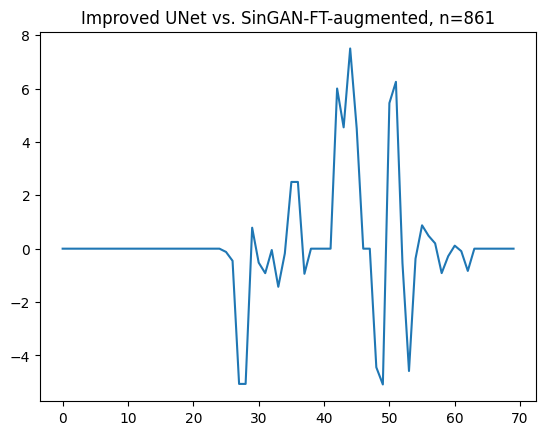

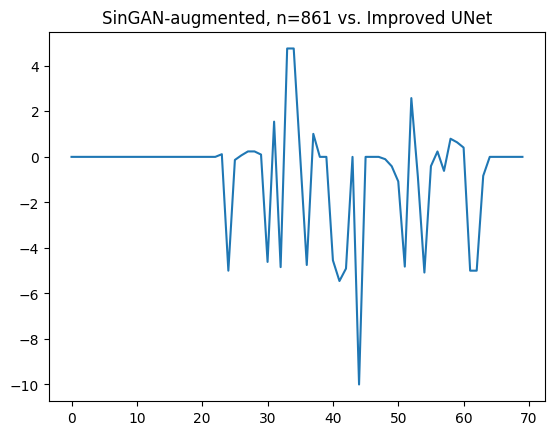

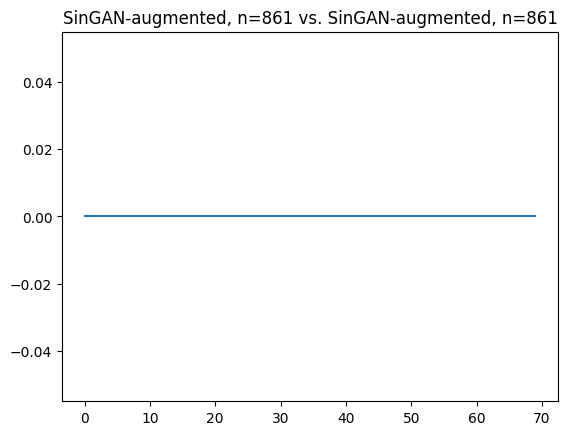

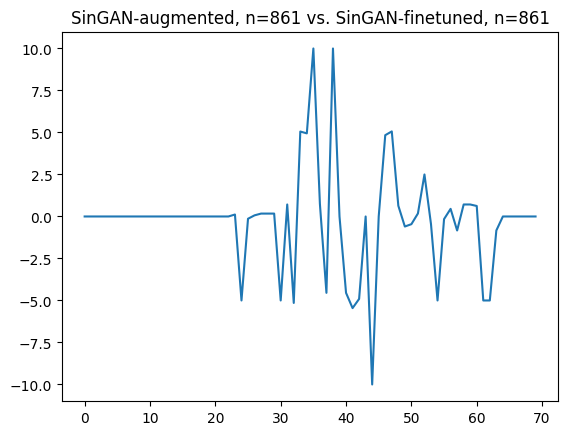

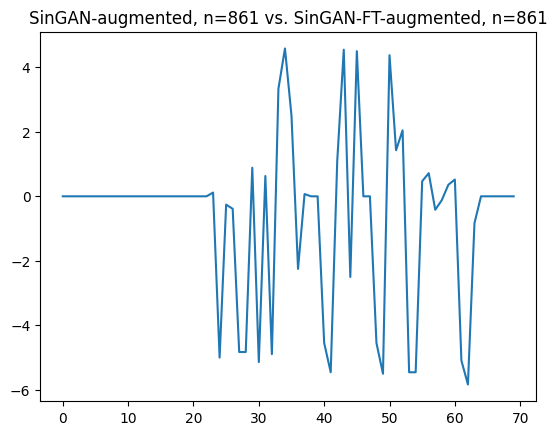

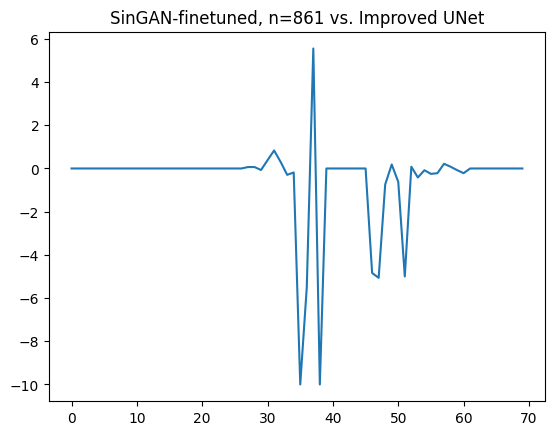

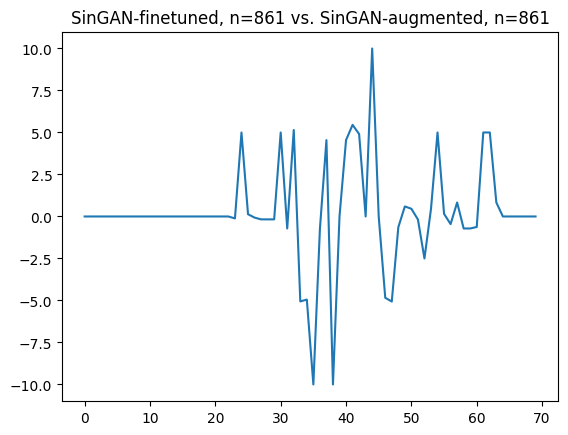

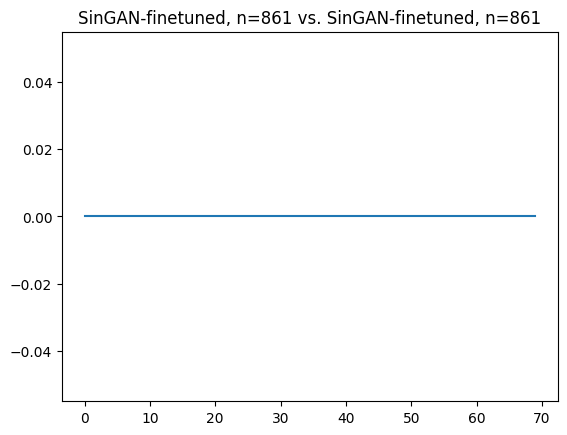

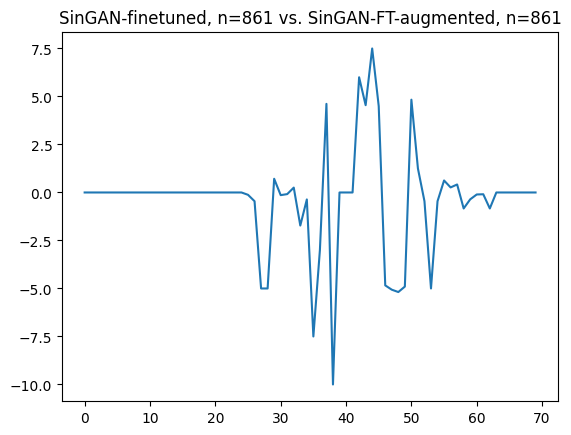

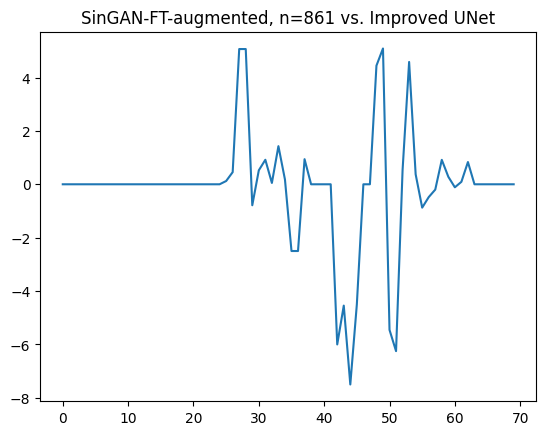

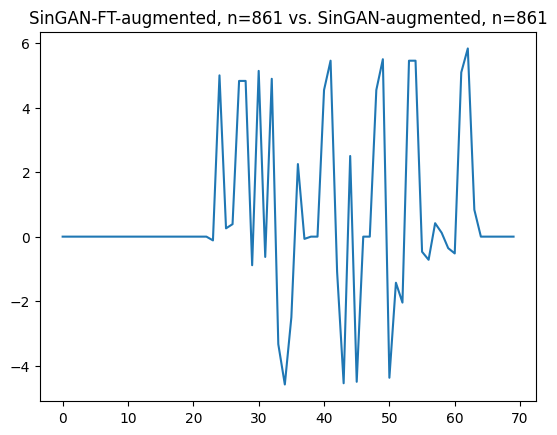

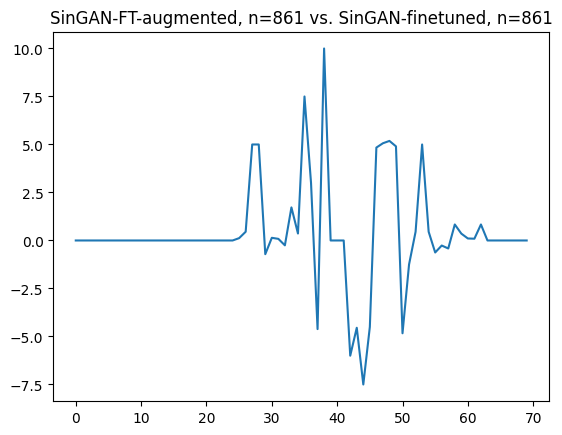

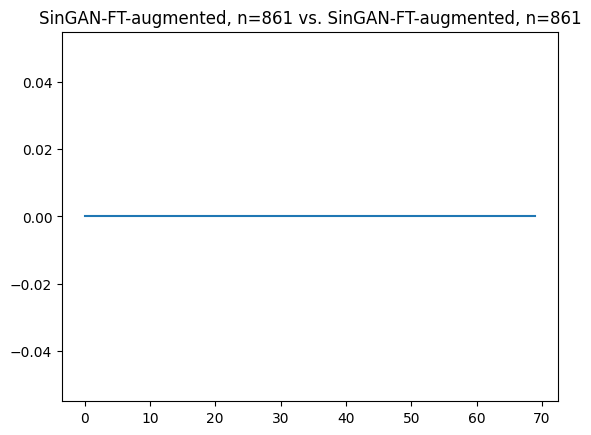

====
Subject: FD_031


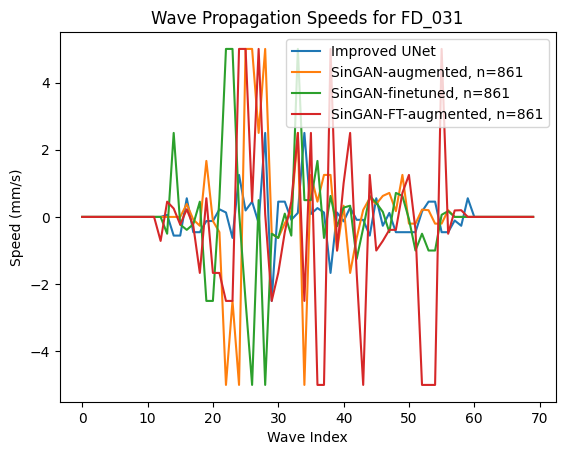

/tmp/ipykernel_1023117/568984630.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plt.imshow(t_test_p_values.fillna(1).values, vmin=-1, vmax=1, cmap='RdBu')


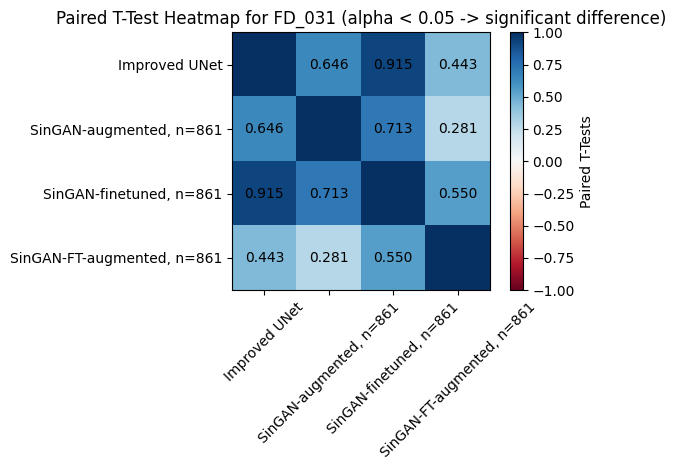

Pairs:
====


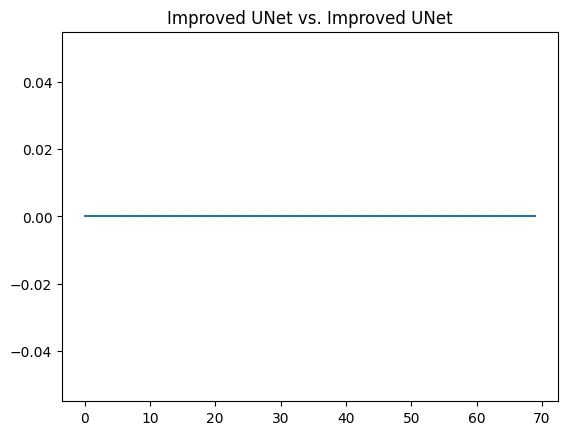

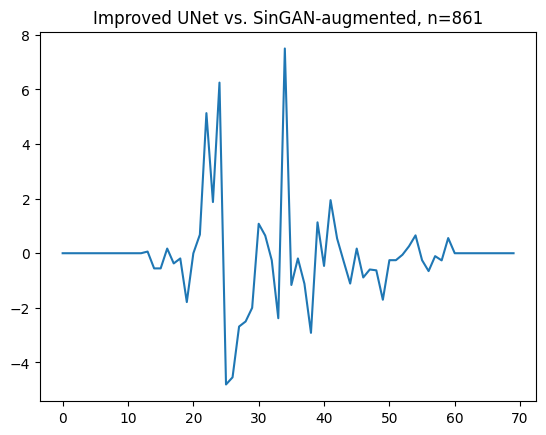

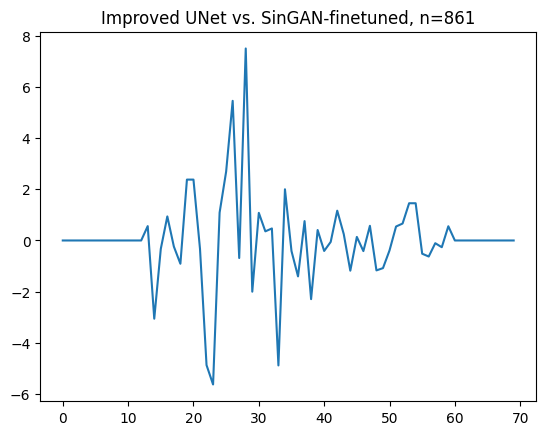

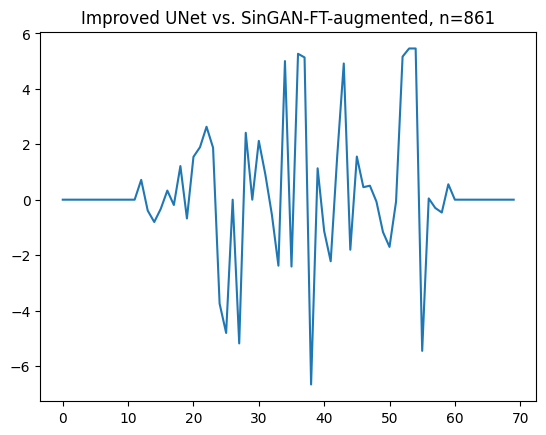

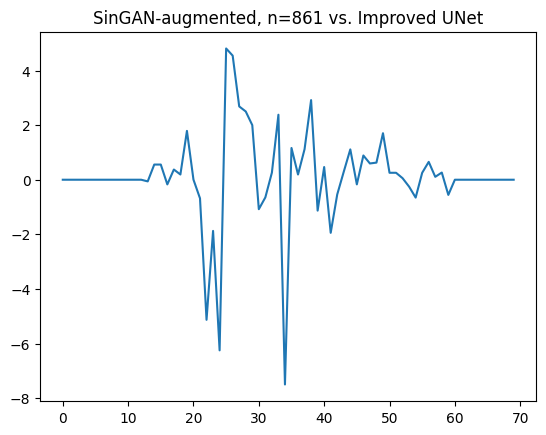

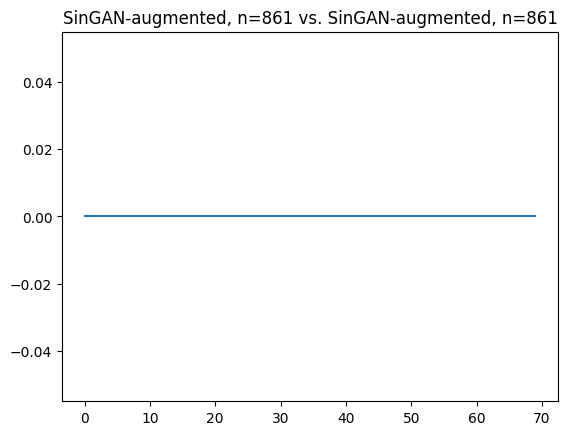

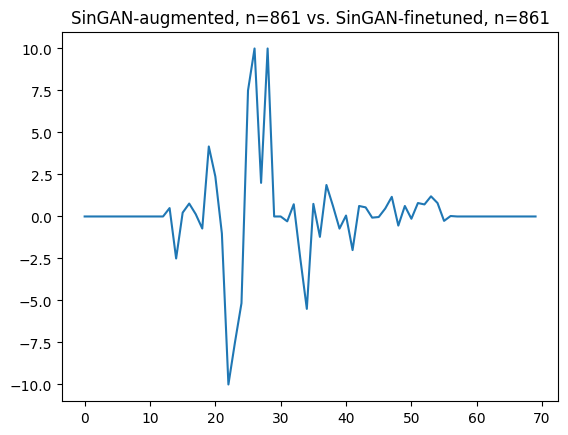

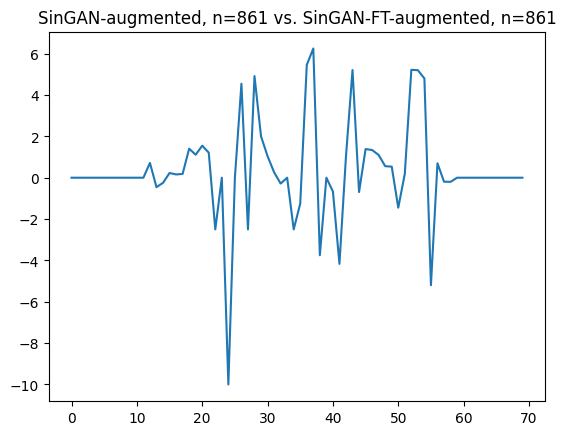

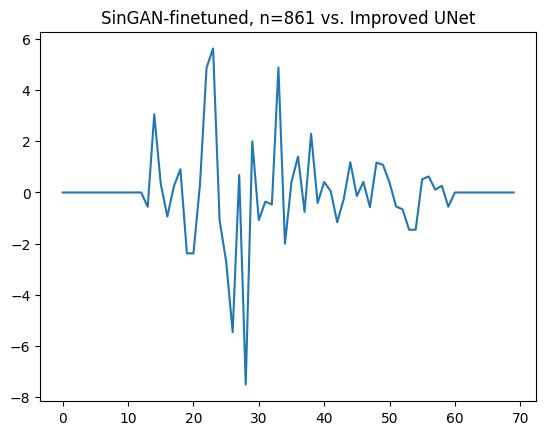

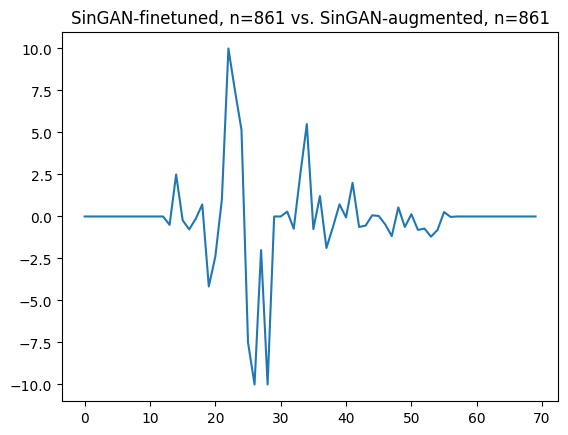

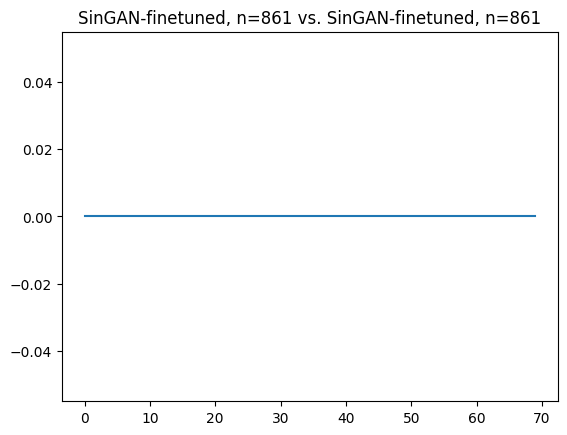

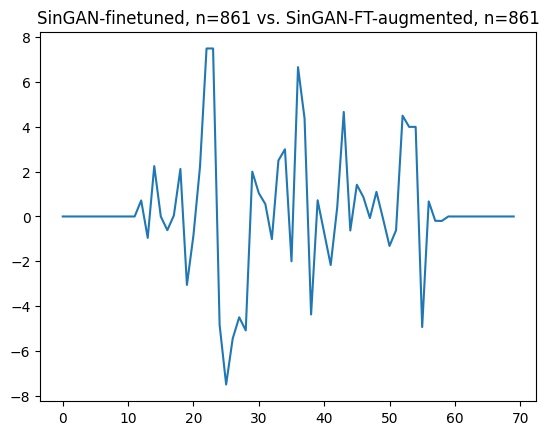

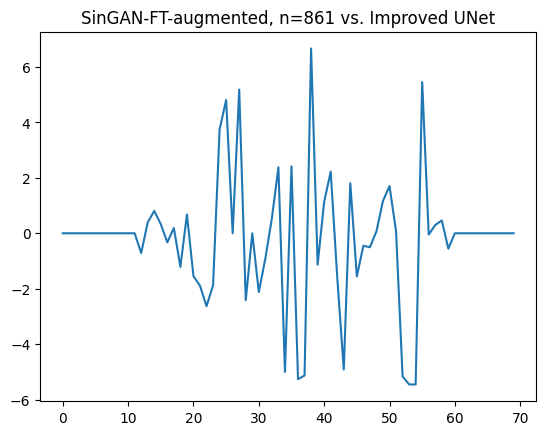

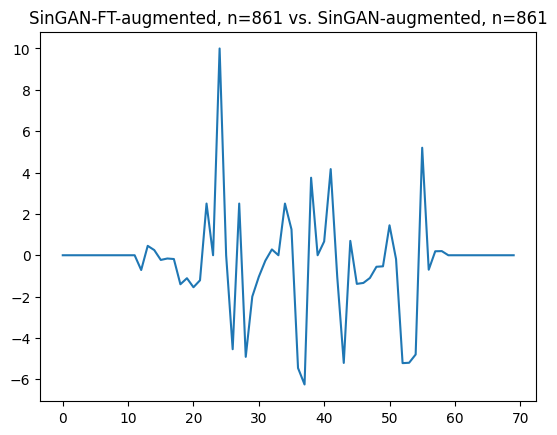

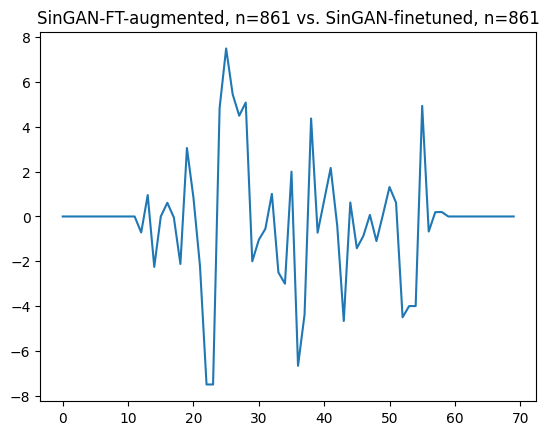

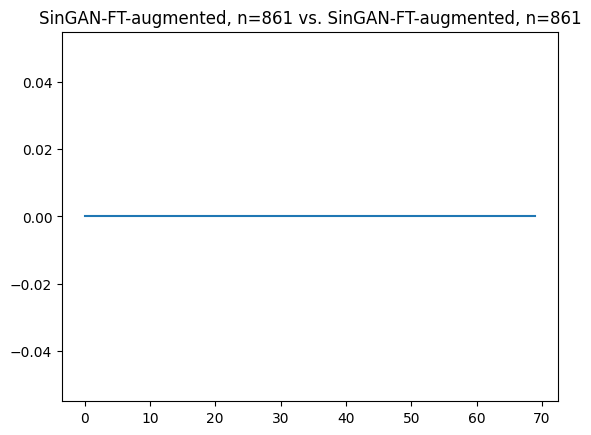

====
Subject: FD_032


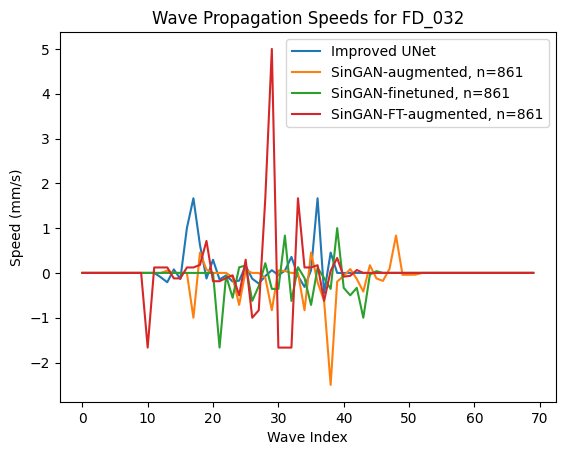

/tmp/ipykernel_1023117/568984630.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  plt.imshow(t_test_p_values.fillna(1).values, vmin=-1, vmax=1, cmap='RdBu')


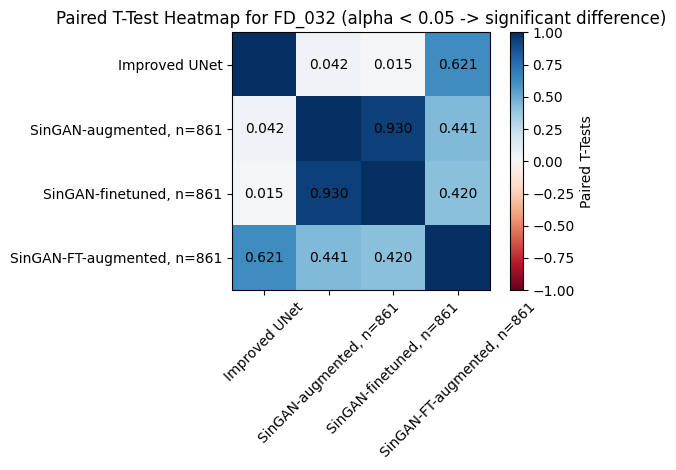

Pairs:
====


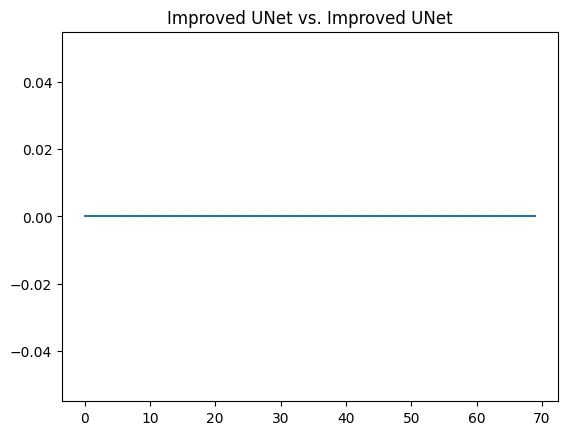

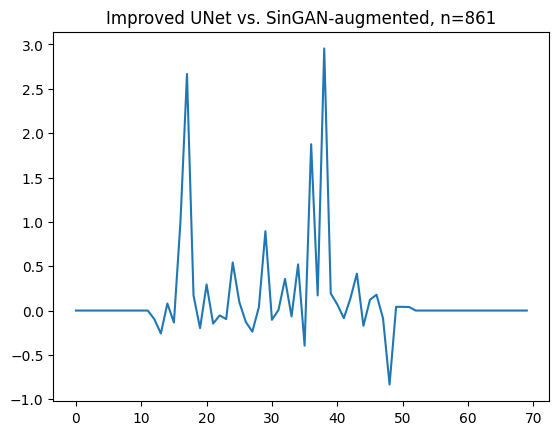

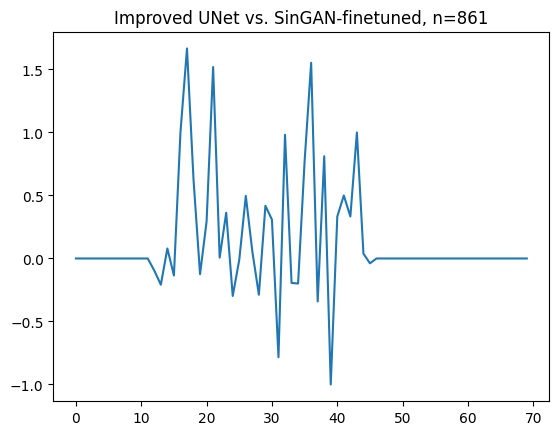

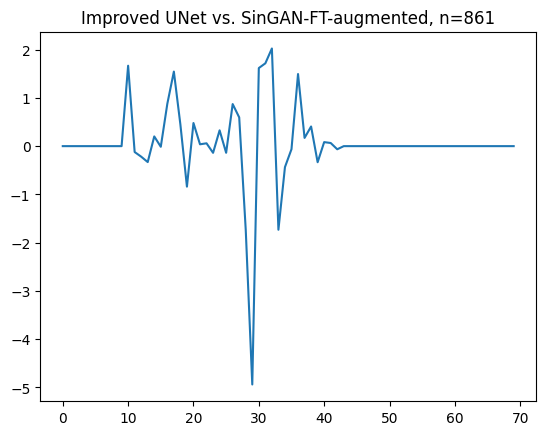

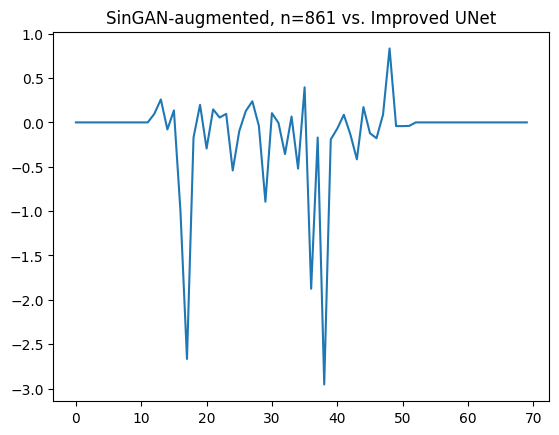

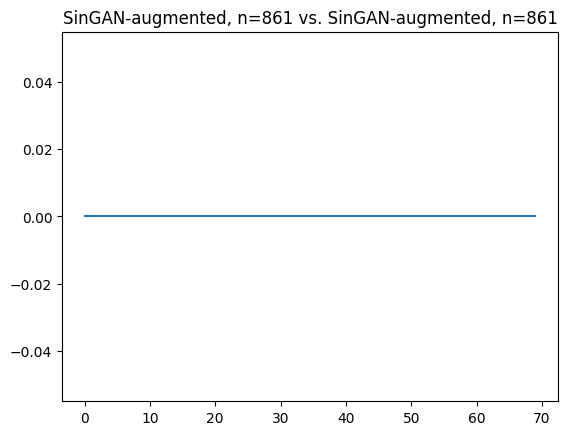

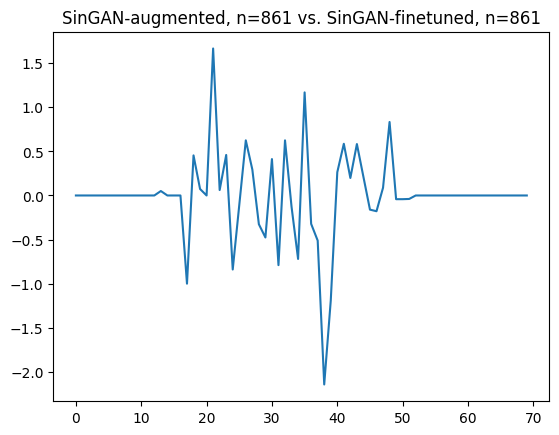

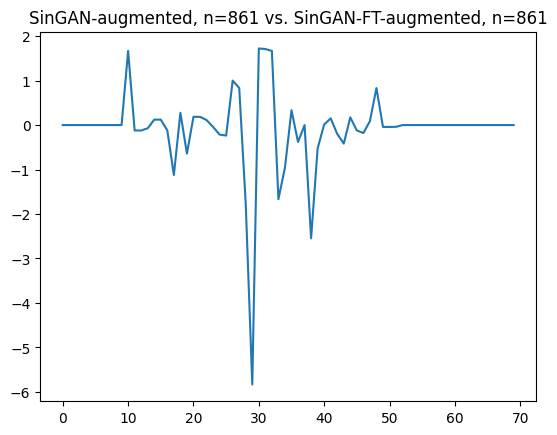

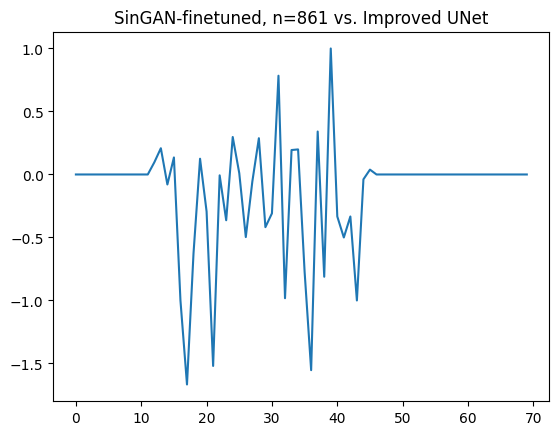

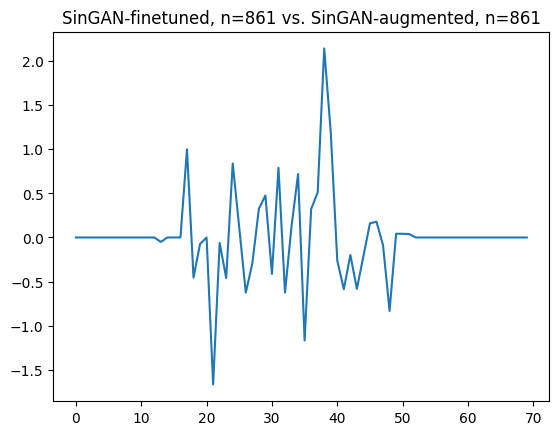

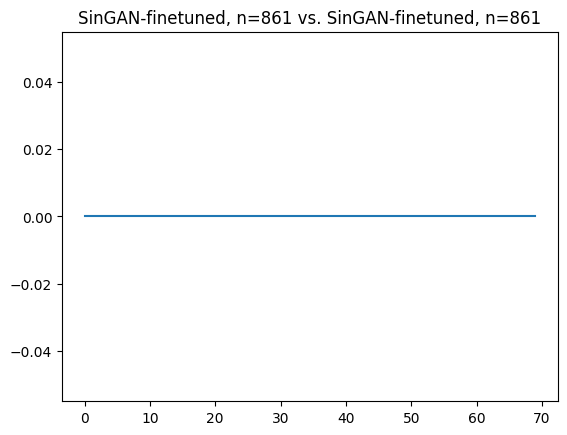

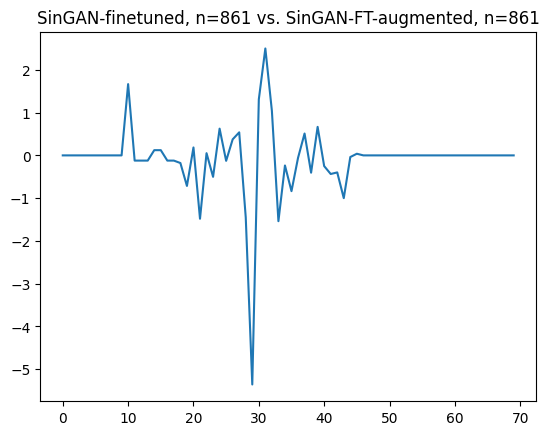

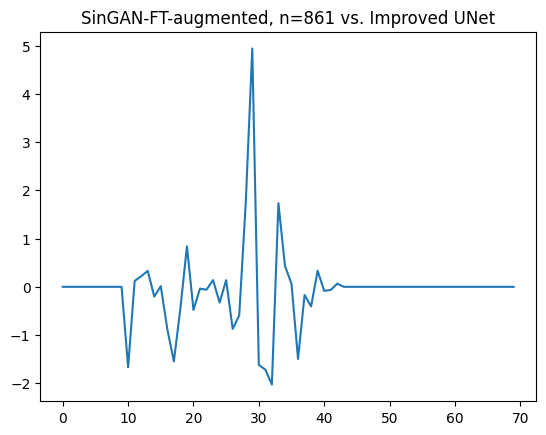

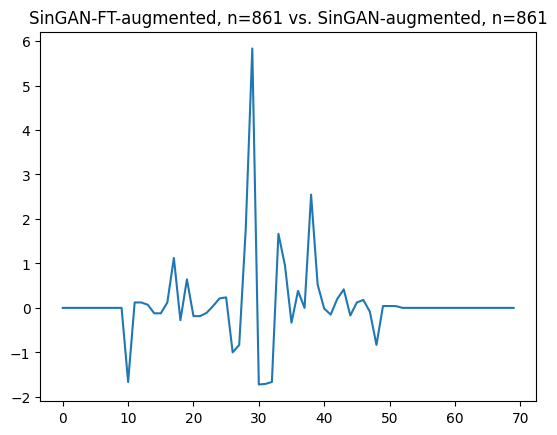

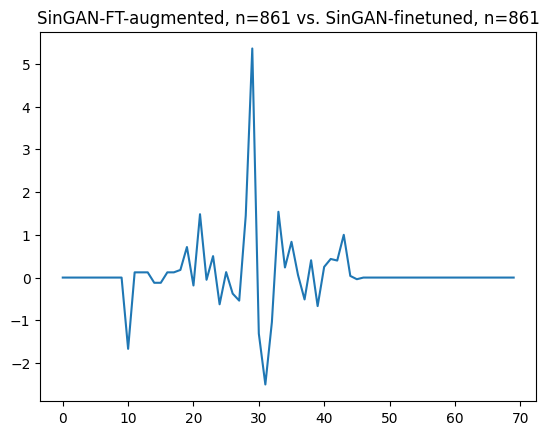

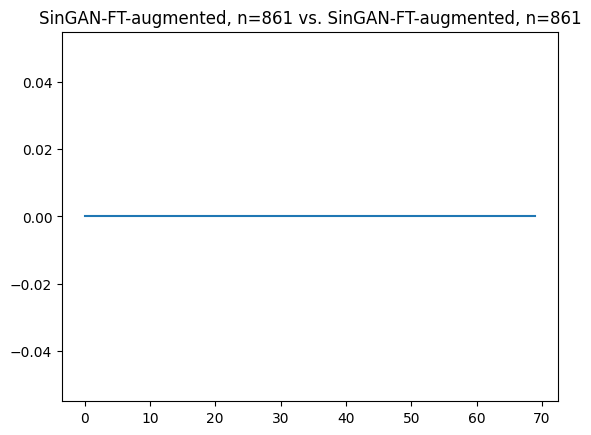

====


In [18]:
for subj, entries in results.items():
    print(f"Subject: {subj}")
    for entry in entries:
        # print(f"  Model: {entry['model']}")
        # print(f"  Stomach Mask Size: {entry['stomach_mask_size']}")
        # print(f"  Dominant Frequency (Hz): {entry['dominant_frequency_hz']}")
        # print(f"  Wave Propagation Speeds (mm/s): {entry['wave_propagation_speeds_mm_s']}")
        plt.plot(
            entry['wave_propagation_speeds_mm_s'],
            label=model_shortnames[entry['model']]
        )
        plt.xlabel('Wave Index')
        plt.ylabel('Speed (mm/s)')
        plt.title(f'Wave Propagation Speeds for {subj}')
        plt.legend()

    plt.show()

    models = [model_shortnames[entry['model']] for entry in entries]

    ts_data = {
        model_shortnames[entry['model']]: entry['wave_propagation_speeds_mm_s']
        for entry in entries
    }

    t_test_p_values = pd.DataFrame(columns=models, index=models)

    for model1 in models:
        for model2 in models:
            t_stat, p_t = ttest_rel(ts_data[model1], ts_data[model2]) 
            t_test_p_values.loc[model1, model2] = p_t if p_t else 0
    
    # Plot heatmap using matplotlib
    plt.figure()
    plt.imshow(t_test_p_values.fillna(1).values, vmin=-1, vmax=1, cmap='RdBu')
    for i in range(len(t_test_p_values.index)):
        for j in range(len(t_test_p_values.columns)):
            value = t_test_p_values.iloc[i, j]
            if pd.notna(value):
                plt.text(j, i, f"{float(value):.3f}", 
                        ha='center', va='center', color='black')
    plt.colorbar(label='Paired T-Tests')
    plt.xticks(range(len(t_test_p_values)), t_test_p_values.columns, rotation=45)
    plt.yticks(range(len(t_test_p_values)), t_test_p_values.index)
    plt.title(f'Paired T-Test Heatmap for {subj} (alpha < 0.05 -> significant difference)')
    plt.tight_layout()
    plt.show()

    print('Pairs:')
    print('====')

    for model1 in models:
        for model2 in models:
            plt.title(f'{model1} vs. {model2}')
            plt.plot(np.array(ts_data[model1]) - np.array(ts_data[model2]))
            plt.show()
    print('====')

In [19]:
t_test_p_values.fillna(1).values

/tmp/ipykernel_1023117/426760303.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  t_test_p_values.fillna(1).values


array([[1.        , 0.0419772 , 0.01500171, 0.62064004],
       [0.0419772 , 1.        , 0.93008827, 0.44075542],
       [0.01500171, 0.93008827, 1.        , 0.42034123],
       [0.62064004, 0.44075542, 0.42034123, 1.        ]])

In [20]:
t_test_p_values

,Improved UNet,"SinGAN-augmented, n=861","SinGAN-finetuned, n=861","SinGAN-FT-augmented, n=861"
Improved UNet,NaN,0.041977,0.015002,0.62064
"SinGAN-augmented, n=861",0.041977,NaN,0.930088,0.440755
"SinGAN-finetuned, n=861",0.015002,0.930088,NaN,0.420341
"SinGAN-FT-augmented, n=861",0.62064,0.440755,0.420341,NaN


Model: uwm-unet-train-set-size-288, CV Subject: FD_027
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
     0

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

   -0.0909    0.1562   -5.0000    0.2632   -5.0000   -5.0000   -5.0000

  Columns 15 through 21

    5.0000    2.5000    0.7143    0.7143   -2.5000   -0.3846   -1.6667

  Columns 22 through 28

    5.0000    0.5556   -0.2941    0.3846   -1.6667   -0.1852    0.1852

  Columns 29 through 35

   -1.2500    0.5000    0.8333       NaN       NaN       NaN       NaN

  Columns 36 through 42

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 43 through 49

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 50 through 56

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 57 through 63

       NaN       NaN       NaN     

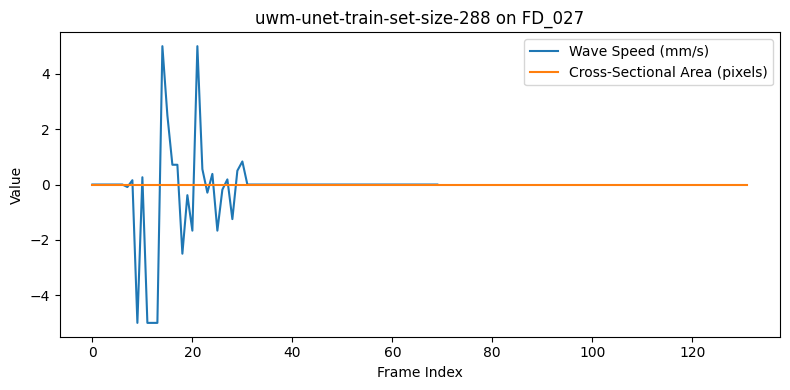

Model: uwm-unet-singan-train-set-size-861, CV Subject: FD_027
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0909

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN   -0.4167   -2.5000   -0.3846    0.2500

  Columns 8 through 14

   -0.1852    0.1852   -0.3571   -0.4545    5.0000    0.8333   -0.2000

  Columns 15 through 21

   -0.0658    2.5000   -2.5000    0.3333    0.3333    0.1136    0.2083

  Columns 22 through 28

   -0.3125   -0.2381   -0.5000    0.1515    0.1724   -0.1087   -5.0000

  Columns 29 through 35

    0.4545   -0.0758    1.6667    0.1136   -0.2632    0.2632    0.1316

  Columns 36 through 42

   -0.3846    0.2778   -0.0877    0.0581   -0.0581    0.1316    0.1136

  Columns 43 through 49

   -0.8333   -0.3846   -0.1852    0.1316   -0.2778    0.1136    0.3846

  Columns 50 through 56

   -0.2778    0.2778    0.1923    0.1923    0.3846   -0.3846    0.3846

  Columns 57 through 63

   -0.3846   -0.3846   -

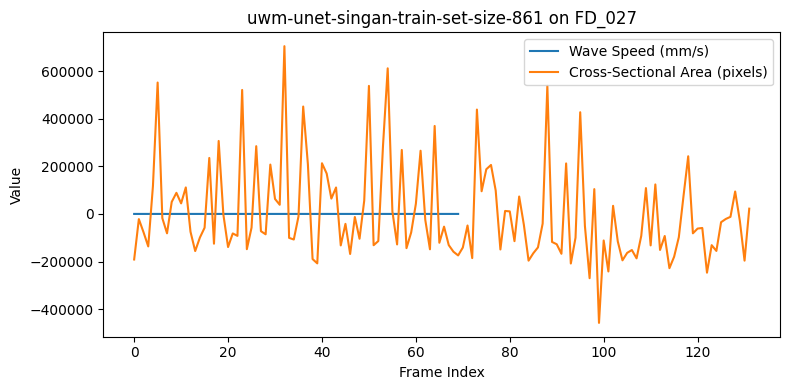

Model: uwm-unet-singan-finetuning-train-set-size-861, CV Subject: FD_027
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0530

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN   -0.1667    0.1667    5.0000    5.0000   -5.0000    5.0000

  Columns 15 through 21

   -5.0000   -2.5000   -1.2500   -2.5000    0.8333   -0.7143    0.1786

  Columns 22 through 28

    0.1316   -0.1786   -1.6667    1.6667   -0.1786   -0.1786    0.4167

  Columns 29 through 35

    0.2000   -0.1471   -0.0820   -0.1724   -0.3571    0.2778   -2.5000

  Columns 36 through 42

   -0.2941   -0.4545   -0.4545    0.4545    0.0562    0.1316    0.2273

  Columns 43 through 49

   -0.4545   -0.2273    0.1020    0.4545    0.2273    0.2273    0.1020

  Columns 50 through 56

    0.2500   -0.1250    0.4545   -1.0000    0.1562   -2.5000    0.0781

  Columns 57 through 63

   -0.0847   

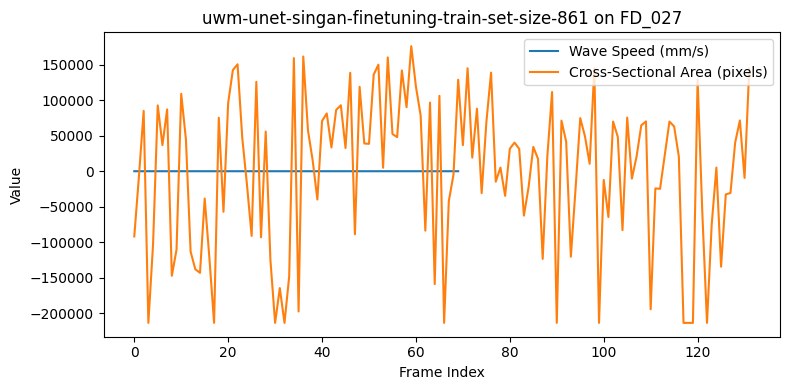

Model: uwm-unet-singan-finetuned-n-10-10x-train-set-size-861, CV Subject: FD_027
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0606

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN   -0.4545    0.7143   -1.2500

  Columns 8 through 14

   -0.7143    1.2500   -1.2500    0.7143   -0.7143    1.2500   -1.2500

  Columns 15 through 21

    5.0000   -2.5000   -2.5000   -0.2941    0.1786    2.5000    5.0000

  Columns 22 through 28

    2.5000   -0.7143   -0.7143   -0.1515    0.7143   -0.2174   -0.7143

  Columns 29 through 35

    1.2500    5.0000   -5.0000   -5.0000    5.0000   -1.6667    1.6667

  Columns 36 through 42

   -0.1613   -0.0515   -1.6667    0.0980   -0.0980   -0.0562    2.5000

  Columns 43 through 49

    0.1042   -0.5000    0.1163   -0.0980   -2.5000   -0.0794    0.1562

  Columns 50 through 56

   -0.2941       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 57 through 63

     

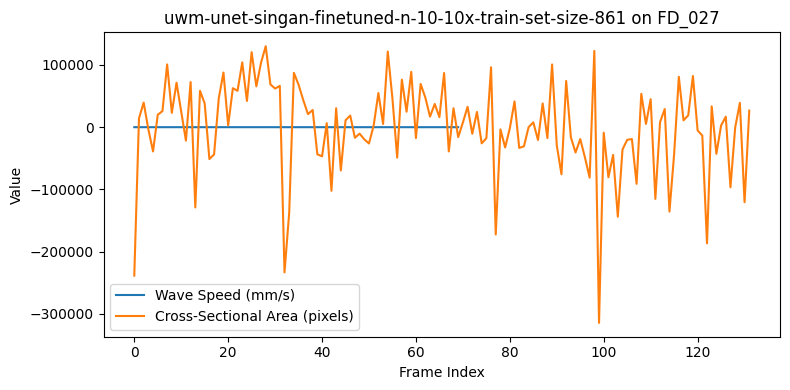

Model: uwm-unet-train-set-size-288, CV Subject: FD_031
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0985

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN       NaN    0.0610

  Columns 15 through 21

   -0.5556   -0.5556    0.5556   -0.4545   -0.4545   -0.1220   -0.1220

  Columns 22 through 28

    0.2273    0.1316   -0.6250    1.2500    0.1923    0.4545   -0.1852

  Columns 29 through 35

    2.5000   -2.5000    0.4545    0.4545   -0.0862    0.1190    2.5000

  Columns 36 through 42

    0.0877    0.2632    0.1316   -1.6667    0.1316   -0.1316    0.2778

  Columns 43 through 49

   -0.0862   -0.0862   -0.5556    0.5556   -0.2632    0.1190   -0.4545

  Columns 50 through 56

   -0.4545   -0.4545   -0.4545    0.1613    0.4545    0.4545   -0.4545

  Columns 57 through 63

   -0.4545   -0.1064   -0.2632 

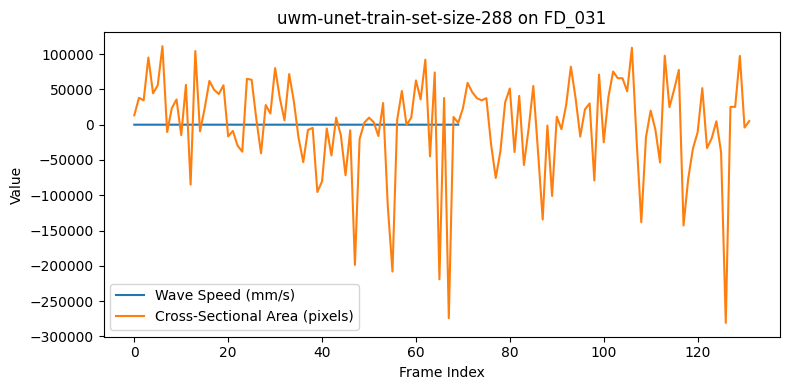

Model: uwm-unet-singan-train-set-size-861, CV Subject: FD_031
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0985

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 15 through 21

       NaN       NaN    0.3846   -0.0806   -0.2632    1.6667   -0.1190

  Columns 22 through 28

   -0.4545   -5.0000   -2.5000   -5.0000    5.0000    5.0000    2.5000

  Columns 29 through 35

    5.0000   -0.5000   -0.6250   -0.1923    0.1724    2.5000   -5.0000

  Columns 36 through 42

    1.2500    0.4545    1.2500    1.2500   -1.0000    0.3333   -1.6667

  Columns 43 through 49

   -0.6250    0.2083    0.5556    0.3846    0.6250    0.7143    0.1724

  Columns 50 through 56

    1.2500   -0.2000   -0.2000    0.2174    0.2000   -0.2000   -0.2000

  Columns 57 through 63

    0.2000       NaN    

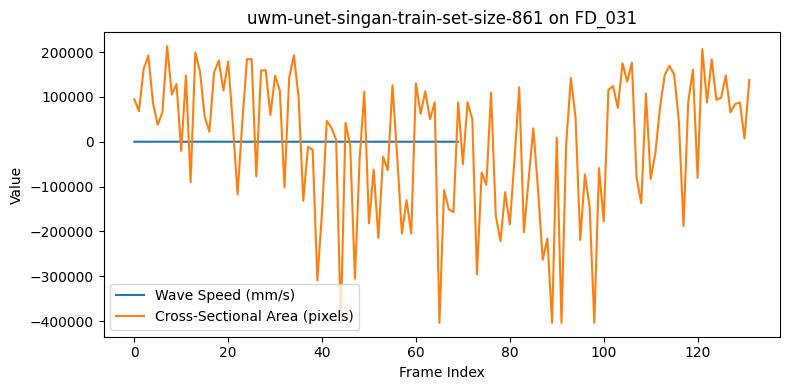

Model: uwm-unet-singan-finetuning-train-set-size-861, CV Subject: FD_031
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0985

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN       NaN   -0.5000

  Columns 15 through 21

    2.5000   -0.2273   -0.3846   -0.2174    0.4545   -2.5000   -2.5000

  Columns 22 through 28

    0.5556    5.0000    5.0000    0.1613   -2.5000   -5.0000    0.5000

  Columns 29 through 35

   -5.0000   -0.5000   -0.6250    0.0980   -0.5556    5.0000    0.5000

  Columns 36 through 42

    0.5000    1.6667   -0.6250    0.6250   -0.2778    0.2778    0.3333

  Columns 43 through 49

   -1.2500   -0.3333    0.6250    0.4167    0.1515   -0.4545    0.7143

  Columns 50 through 56

    0.6250   -0.0649   -1.0000   -0.5000   -1.0000   -1.0000    0.0625

  Columns 57 through 63

    0.1724   

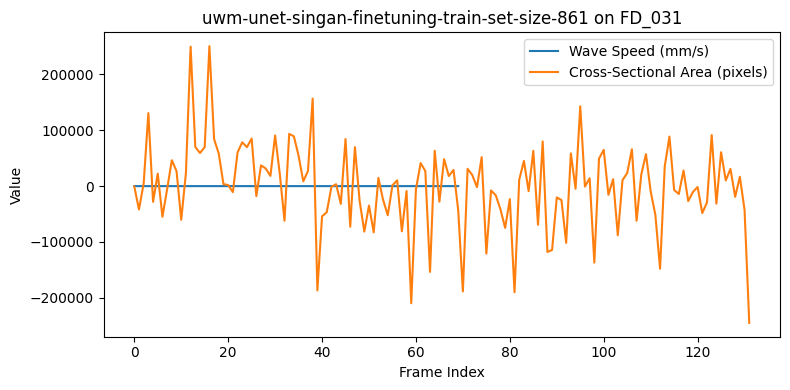

Model: uwm-unet-singan-finetuned-n-10-10x-train-set-size-861, CV Subject: FD_031
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0985

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN   -0.7143    0.4545

  Columns 15 through 21

    0.2500   -0.2273    0.2273   -0.2632   -1.6667    0.5556   -1.6667

  Columns 22 through 28

   -1.6667   -2.5000   -2.5000    5.0000    5.0000    0.4545    5.0000

  Columns 29 through 35

    0.0862   -2.5000   -1.6667   -0.4545    0.4545    2.5000   -2.5000

  Columns 36 through 42

    2.5000   -5.0000   -5.0000    5.0000   -1.0000    1.0000    2.5000

  Columns 43 through 49

   -1.6667   -5.0000    1.2500   -1.0000   -0.7143   -0.3846   -0.3846

  Columns 50 through 56

    0.7143    1.2500   -0.3846   -5.0000   -5.0000   -5.0000    5.0000

  Columns 57 through 63

   -0

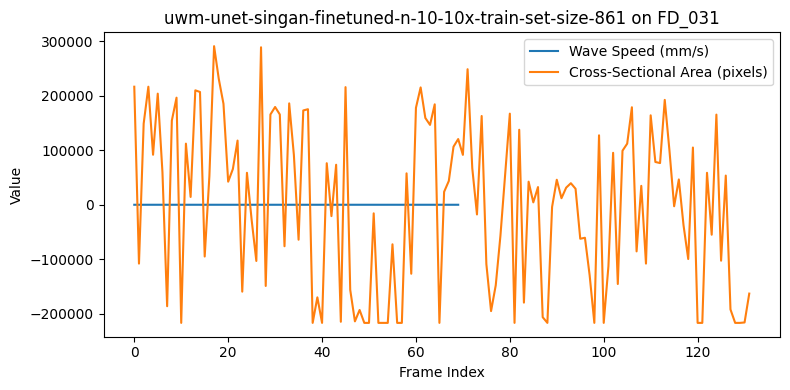

Model: uwm-unet-train-set-size-288, CV Subject: FD_030
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0985

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 15 through 21

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 22 through 28

       NaN       NaN       NaN       NaN       NaN       NaN   -0.0667

  Columns 29 through 35

   -0.0667    0.0714   -0.3846   -0.8333   -0.1562    0.2381    0.2381

  Columns 36 through 42

    5.0000    5.0000   -0.5556    5.0000    5.0000    5.0000    5.0000

  Columns 43 through 49

    5.0000    5.0000    5.0000    5.0000    5.0000    5.0000    0.5556

  Columns 50 through 56

   -0.0877    0.4545    5.0000   -0.0820    0.4167    0.0820    0.2500

  Columns 57 through 63

    0.2174   -0.2174   -0.0820 

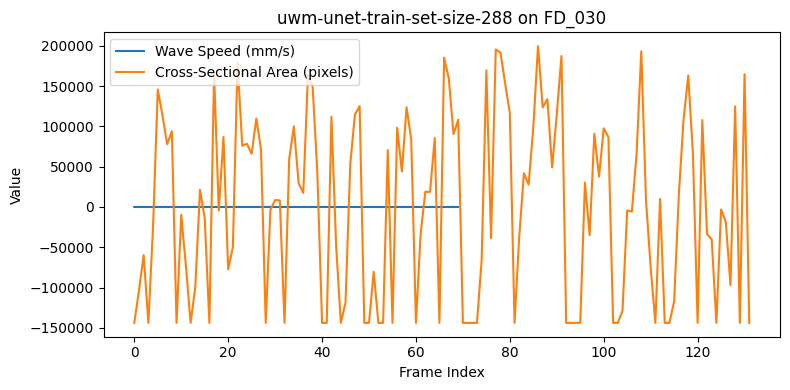

Model: uwm-unet-singan-train-set-size-861, CV Subject: FD_030
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0985

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 15 through 21

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 22 through 28

       NaN       NaN    0.1163   -5.0000   -0.1351    0.0676    0.1724

  Columns 29 through 35

    0.1724    0.1724   -5.0000    0.7143   -5.0000    5.0000    5.0000

  Columns 36 through 42

    5.0000    0.2500    0.4545    5.0000    5.0000    0.4545   -0.4545

  Columns 43 through 49

    0.0926    5.0000   -5.0000    5.0000    5.0000    5.0000    0.4545

  Columns 50 through 56

   -0.5000   -0.6250    0.1786    2.5000   -0.4545   -5.0000   -0.1562

  Columns 57 through 63

    0.4545   -0.8333    

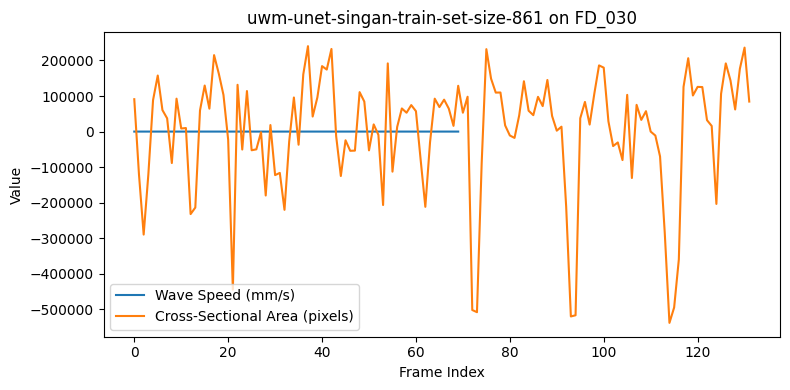

Model: uwm-unet-singan-finetuning-train-set-size-861, CV Subject: FD_030
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0530

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 15 through 21

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 22 through 28

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 29 through 35

       NaN       NaN       NaN       NaN    0.1471   -0.0562    0.0532

  Columns 36 through 42

   -5.0000   -0.5000    5.0000   -5.0000    5.0000    5.0000    5.0000

  Columns 43 through 49

    5.0000    5.0000    5.0000    5.0000    0.1613   -0.0633   -0.1852

  Columns 50 through 56

    0.0980   -0.1667       NaN       NaN       NaN       NaN       NaN

  Columns 57 through 63

       NaN   

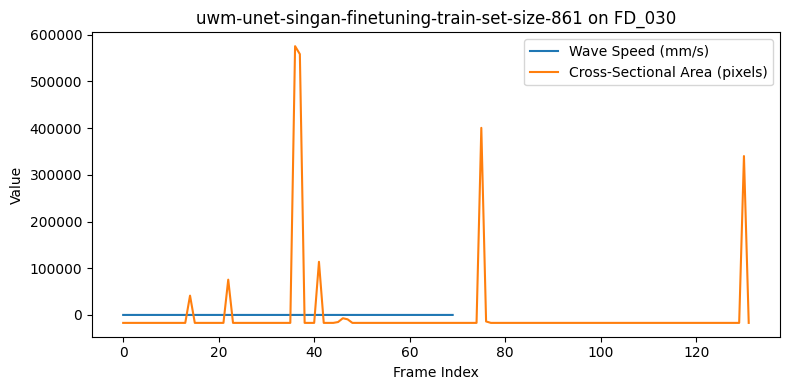

Model: uwm-unet-singan-finetuned-n-10-10x-train-set-size-861, CV Subject: FD_030
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0985

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 15 through 21

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 22 through 28

       NaN       NaN       NaN       NaN    0.1220    0.4545    5.0000

  Columns 29 through 35

    5.0000   -0.7143    0.1389    0.0847   -0.1064    1.6667    0.4167

  Columns 36 through 42

    2.5000    2.5000    0.3846    5.0000    5.0000    5.0000    5.0000

  Columns 43 through 49

   -1.0000    0.4545   -2.5000    0.5000    5.0000    5.0000    5.0000

  Columns 50 through 56

    5.0000   -5.0000   -1.2500    0.4545    5.0000    0.4545   -0.6250

  Columns 57 through 63

   -0

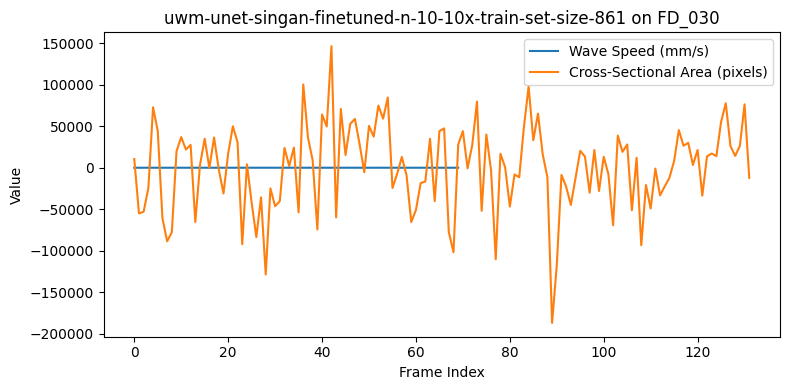

Model: uwm-unet-train-set-size-288, CV Subject: FD_029
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.1364

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 15 through 21

       NaN       NaN       NaN       NaN       NaN   -5.0000   -5.0000

  Columns 22 through 28

    5.0000    5.0000   -5.0000    5.0000   -5.0000   -1.6667    1.6667

  Columns 29 through 35

    0.4545   -0.8333    2.5000    2.5000    0.1220    0.1316    0.1724

  Columns 36 through 42

   -5.0000   -0.1667   -0.1220   -0.6250   -0.1786    2.5000    0.1613

  Columns 43 through 49

   -0.0704   -0.0980   -0.1613   -0.1613   -0.1042    0.3333   -0.1613

  Columns 50 through 56

   -0.1613    0.1613   -0.1613    0.1613    0.1613    0.5000    0.1667

  Columns 57 through 63

   -0.1667   -0.1667   -0.1852 

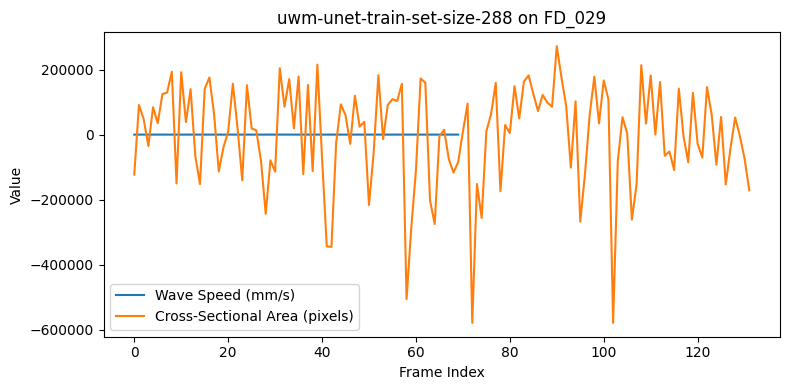

Model: uwm-unet-singan-train-set-size-861, CV Subject: FD_029
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0909

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 15 through 21

       NaN       NaN       NaN       NaN    1.2500   -1.2500   -1.2500

  Columns 22 through 28

   -0.2941    5.0000    5.0000   -5.0000    5.0000   -1.2500    0.8333

  Columns 29 through 35

    0.1515    0.2083    0.2381   -0.1220   -0.5556   -0.5556   -0.2381

  Columns 36 through 42

    0.2500   -0.2174    0.3125    0.1471   -0.0641    0.1087    0.8333

  Columns 43 through 49

   -0.1667    0.1667    0.0694    0.2778   -1.0000    0.1515   -0.2273

  Columns 50 through 56

    1.2500    0.2941    0.2941    1.2500    1.2500    1.2500   -0.2000

  Columns 57 through 63

    0.2000   -1.2500    

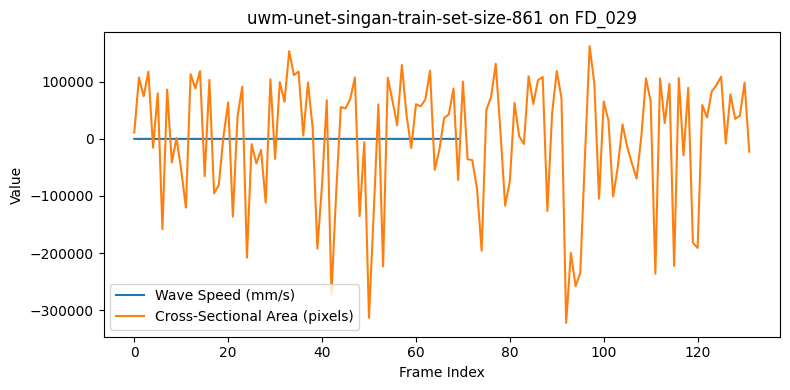

Model: uwm-unet-singan-finetuning-train-set-size-861, CV Subject: FD_029
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0682

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 15 through 21

       NaN       NaN       NaN       NaN   -0.2941    0.3125    0.3846

  Columns 22 through 28

    2.5000    2.5000    2.5000    0.0526    2.5000   -0.2632    0.5000

  Columns 29 through 35

    0.4545    0.4545    1.2500   -0.4545    0.4545    0.1515    1.2500

  Columns 36 through 42

    0.1852    0.3571    1.0000   -0.7143    5.0000   -0.0667   -0.1724

  Columns 43 through 49

   -1.6667    0.5556    1.6667    1.2500    5.0000    1.2500    1.2500

  Columns 50 through 56

    1.2500    1.2500   -1.2500    1.2500   -1.2500    1.2500   -1.2500

  Columns 57 through 63

   -1.2500   

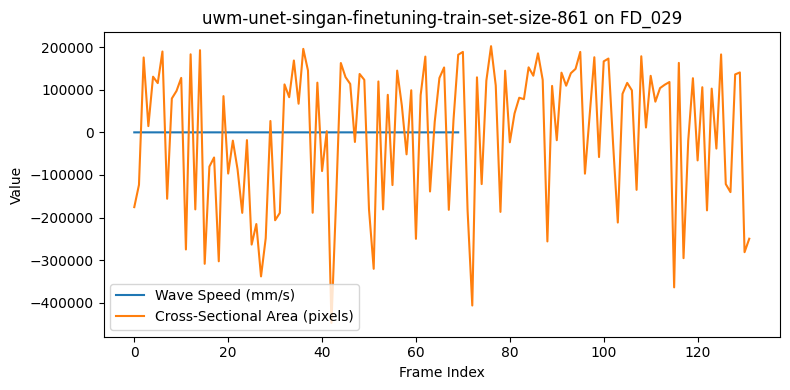

Model: uwm-unet-singan-finetuned-n-10-10x-train-set-size-861, CV Subject: FD_029
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.0606

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 15 through 21

       NaN       NaN       NaN       NaN    1.2500   -1.2500   -0.1852

  Columns 22 through 28

   -0.1724    0.5556    0.3571   -5.0000    2.5000    2.5000    5.0000

  Columns 29 through 35

    1.0000    5.0000   -5.0000    0.4167    0.5556   -1.6667   -0.2778

  Columns 36 through 42

    1.2500   -1.2500    1.2500   -1.2500   -1.2500    1.2500   -1.2500

  Columns 43 through 49

    1.2500    1.2500    1.2500   -1.2500    0.8333   -5.0000    1.2500

  Columns 50 through 56

    0.2941   -0.2941   -1.2500   -0.5556    1.2500    1.2500   -0.5556

  Columns 57 through 63

    1

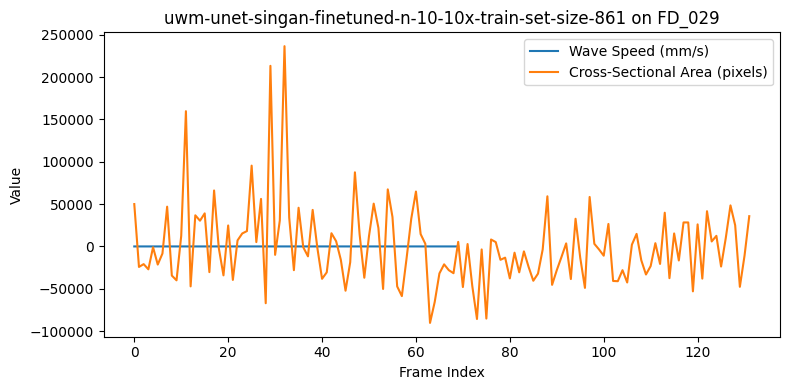

Model: uwm-unet-train-set-size-288, CV Subject: FD_032
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.1288

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN   -0.0962   -0.2083

  Columns 15 through 21

    0.0794   -0.1351    1.0000    1.6667    0.6250   -0.1250    0.2941

  Columns 22 through 28

   -0.1471   -0.0549   -0.1923   -0.1724    0.1562   -0.1282   -0.2381

  Columns 29 through 35

   -0.0704    0.0610   -0.0485    0.0495    0.3571   -0.0658   -0.3125

  Columns 36 through 42

    0.0588    1.6667   -0.4545    0.4545       NaN       NaN       NaN

  Columns 43 through 49

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 50 through 56

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 57 through 63

       NaN       NaN       NaN 

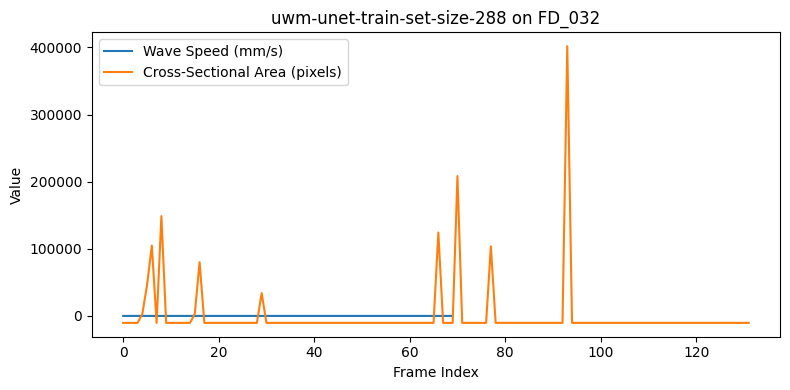

Model: uwm-unet-singan-train-set-size-861, CV Subject: FD_032
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.1818

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN       NaN    0.0505

  Columns 15 through 21

       NaN       NaN       NaN   -1.0000    0.4545    0.0735       NaN

  Columns 22 through 28

       NaN       NaN   -0.0962   -0.7143    0.0581       NaN       NaN

  Columns 29 through 35

   -0.1087   -0.8333    0.0556    0.0435       NaN       NaN   -0.8333

  Columns 36 through 42

    0.4545   -0.2083   -0.6250   -2.5000   -0.1923   -0.0694    0.0862

  Columns 43 through 49

   -0.1351   -0.4167    0.1724   -0.1220   -0.1786    0.0877    0.8333

  Columns 50 through 56

   -0.0420   -0.0420   -0.0394       NaN       NaN       NaN       NaN

  Columns 57 through 63

       NaN       NaN    

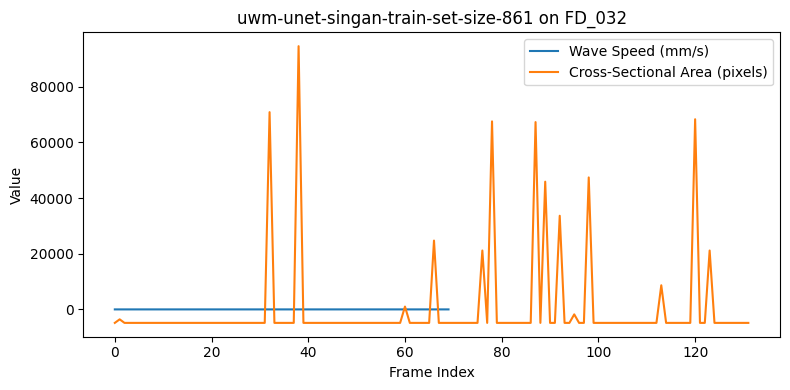

Model: uwm-unet-singan-finetuning-train-set-size-861, CV Subject: FD_032
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.1970

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 15 through 21

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 22 through 28

   -1.6667   -0.0617   -0.5556    0.1250    0.1667   -0.6250   -0.2941

  Columns 29 through 35

    0.2174   -0.3571   -0.3571    0.8333   -0.6250    0.1282   -0.1136

  Columns 36 through 42

   -0.7143    0.1136   -0.1136   -0.3571    1.0000   -0.3333   -0.5000

  Columns 43 through 49

   -0.3333   -1.0000   -0.0385    0.0385       NaN       NaN       NaN

  Columns 50 through 56

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 57 through 63

       NaN   

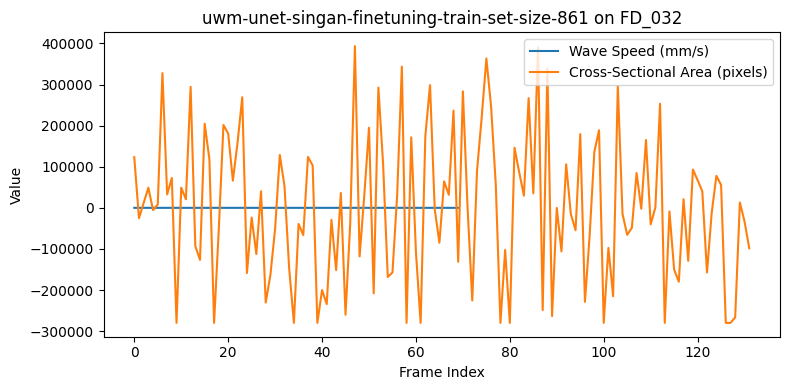

Model: uwm-unet-singan-finetuned-n-10-10x-train-set-size-861, CV Subject: FD_032
Size of stomachMask:
   256   256    71   132

Dominant Frequency (Hz):
    0.1894

Wave propagation speeds (mm/s):
  Columns 1 through 7

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 8 through 14

       NaN       NaN       NaN   -1.6667    0.1220    0.1220    0.1220

  Columns 15 through 21

   -0.1220   -0.1220    0.1220    0.1220    0.1786    0.7143   -0.1852

  Columns 22 through 28

   -0.1852   -0.1136   -0.0538   -0.5000    0.2941   -1.0000   -0.8333

  Columns 29 through 35

    1.6667    5.0000   -1.6667   -1.6667   -1.6667    1.6667    0.1220

  Columns 36 through 42

    0.1220    0.1724   -0.6250    0.0472    0.3333   -0.0833   -0.0649

  Columns 43 through 49

    0.0649       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 50 through 56

       NaN       NaN       NaN       NaN       NaN       NaN       NaN

  Columns 57 through 63

     

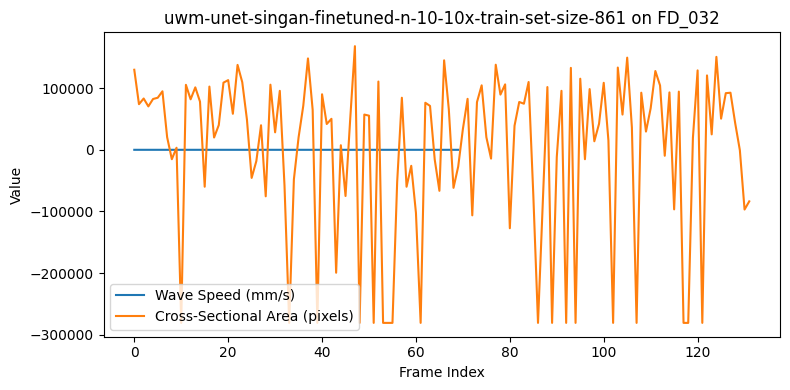

In [21]:
for cv_subject in cv_subjects:
    for model_data in output_data:
        if model_data['cv_subject'] != cv_subject:
            continue
        total_area = model_data['cross_section_data']
        print(f"Model: {model_data['model']}, CV Subject: {cv_subject}")
        print(model_data['matlab_output'])
        selected_model = [res for res in results[cv_subject] if res['model'] == model_data['model']][0]


        wave_speeds = selected_model['wave_propagation_speeds_mm_s']

        plt.figure(figsize=(8,4))
        plt.plot(wave_speeds, label='Wave Speed (mm/s)')
        plt.plot(total_area,  label='Cross‐Sectional Area (pixels)')
        plt.xlabel('Frame Index')
        plt.ylabel('Value')
        plt.title(f"{model_data['model']} on {cv_subject}")
        plt.legend()
        plt.tight_layout()
        plt.show()
